# Assignment 2: Rectangles and Sampling

**Student Name:** Sheylle Green and Marc Wijnands 

**Group Number:** 20

## Setup and Imports

In [31]:
import diplib as dip
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import defaultdict

In [ ]:
## TEAMMATE 1 TO RUN
def load_image(series, number):
    img = dip.ImageRead(f'D:/02_School/MSc/02_Sem2627-2/Image_Analysis/Assignment2/Assignment2/rect{number}{series}.tif')
    return img
## TEAMMATE 2 TO RUN
#def load_image(series, number):
	#img = dip.ImageRead(f'/home/nessinmorse/Programming/Python/A2_Imaging/ImageAnalysis_Assignments/Assignment2/rect{number}{series}.tif')
	#return img

---
# Part 2.1: Histograms and Measurements (Series A)
## Questions 1-3

### Q1: Compute histograms of series A (4 plots)

Rect1a


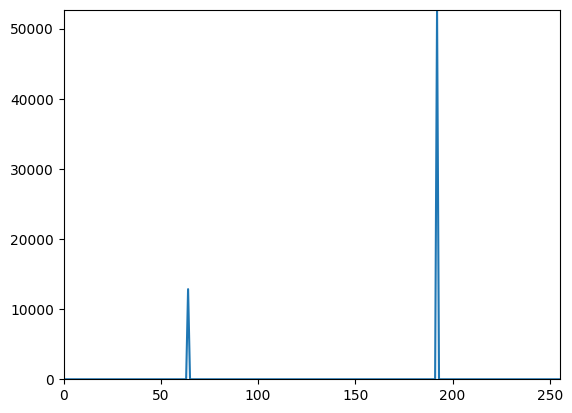

Rect2a


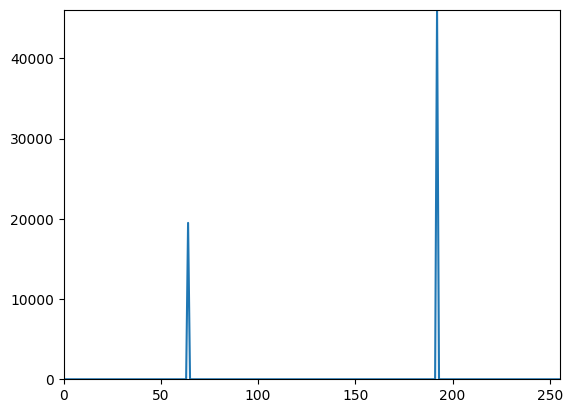

Rect3a


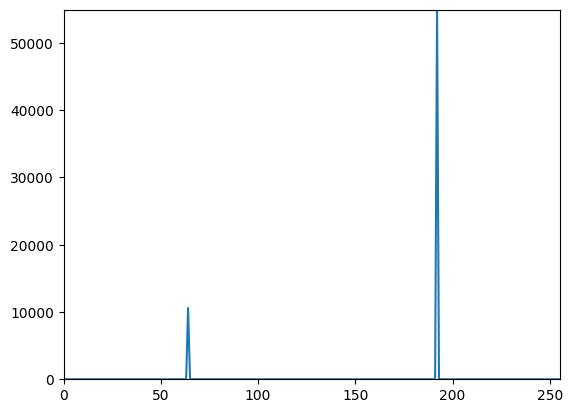

Rect4a


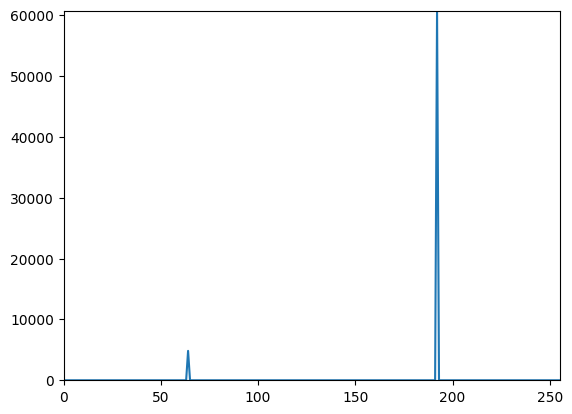

In [33]:
# Q1: Histograms for Series A
for i in range(1, 5):
    img = load_image('a', i)
    hist = dip.Histogram(img) 
    print(f"Rect{i}a")
    hist.Show() 


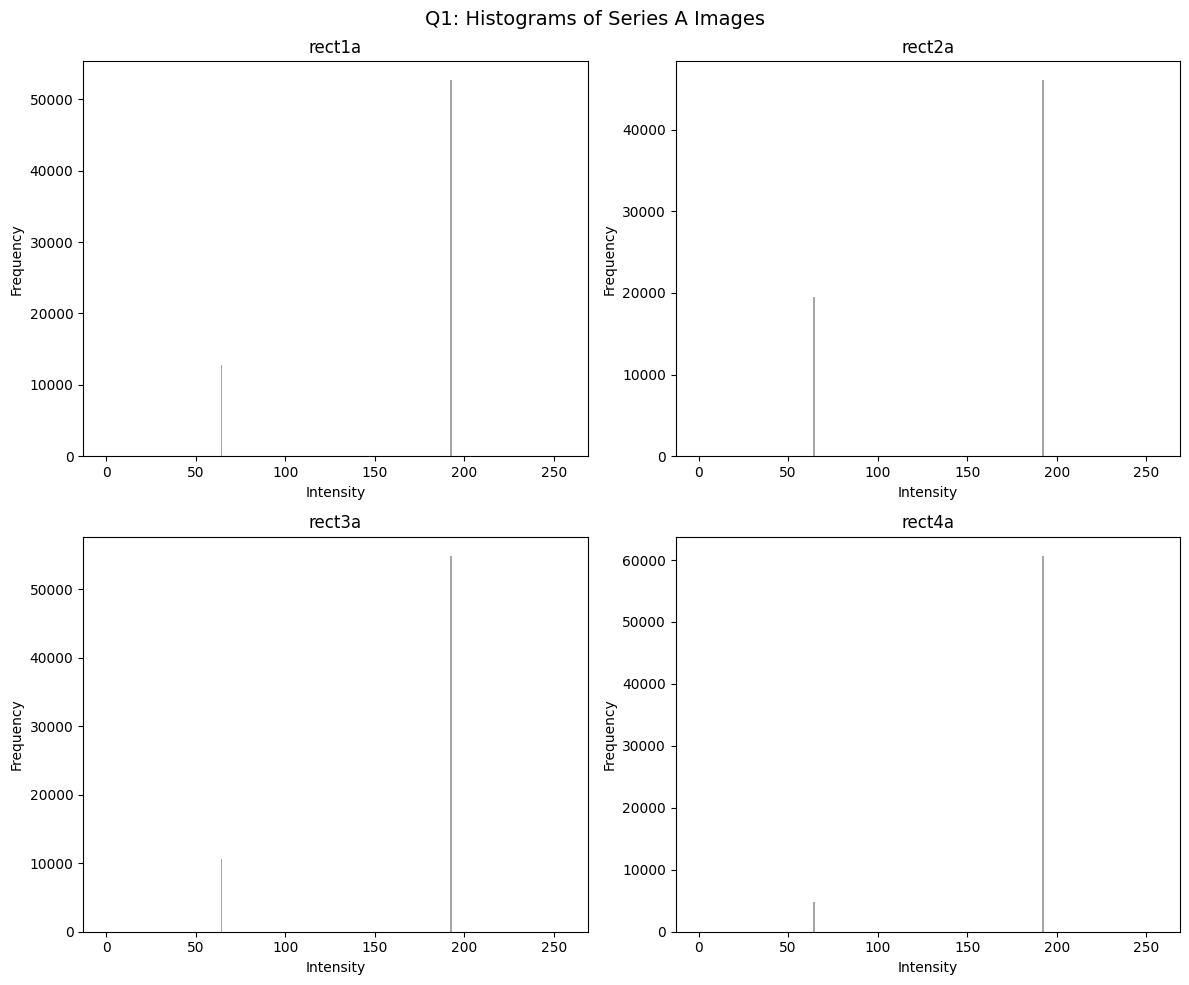

In [34]:
## Extra code (For visual in report)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(1, 5):
    img = load_image('a', i)
    axes[i-1].hist(np.array(img).flatten(), bins=256, range=(0,256), color='gray', alpha=0.7)
    axes[i-1].set_title(f'rect{i}a')
    axes[i-1].set_xlabel('Intensity')
    axes[i-1].set_ylabel('Frequency')

plt.suptitle('Q1: Histograms of Series A Images', fontsize=14)
plt.tight_layout()
plt.show()

### Q2-Q3: Measure area and perimeter (mean and std)

In [35]:
import numpy as np
import diplib as dip
import pandas as pd

tool = dip.MeasurementTool

all_results = []
summary_results = []
results_A = { 'area': {'means': [], 'stds': []}, 'perimeter': {'means': [], 'stds': []} }

for i in range(1,5):
    image = dip.ImageReadTIFF(f'rect{i}a.tif')
    img = 255 - image
    binary = dip.IsodataThreshold(img) 
    label = dip.Label(binary, connectivity=2)
    
    msr = tool.Measure(label, img, ["SolidArea", "Perimeter"])
    
    areas = np.array(msr["SolidArea"])
    perimeters = np.array(msr["Perimeter"])

    results_A['area']['means'].append(np.mean(areas))
    results_A['area']['stds'].append(np.std(areas))
    results_A['perimeter']['means'].append(np.mean(perimeters)) 
    results_A['perimeter']['stds'].append(np.std(perimeters))
    
    for obj_id in range(len(areas)):
        all_results.append({
            "Image": f"rect{i}a",
            "Object_ID": obj_id + 1,
            "Area": areas[obj_id],
            "Perimeter": perimeters[obj_id]
        })
    
    summary_results.append({
        "Image": f"rect{i}a",
        "Object_Count": len(areas),
        "Mean_Area": np.mean(areas),
        "Std_Area": np.std(areas),
        "Mean_Perimeter": np.mean(perimeters),
        "Std_Perimeter": np.std(perimeters)
    })


df_objects = pd.DataFrame(all_results)
df_summary = pd.DataFrame(summary_results)


print(df_objects)



     Image  Object_ID       Area             Perimeter
0   rect1a          1  [12848.0]   [457.4975926535898]
1   rect2a          1   [3195.0]   [233.7335926535898]
2   rect2a          2   [3285.0]  [230.13759265358976]
3   rect2a          3   [3265.0]  [234.67559265358975]
4   rect2a          4   [3248.0]   [235.9775926535898]
5   rect2a          5   [3230.0]  [233.26959265358977]
6   rect2a          6   [3262.0]  [235.06959265358978]
7   rect3a          1   [1320.0]  [143.89759265358978]
8   rect3a          2   [1328.0]  [148.76959265358977]
9   rect3a          3   [1335.0]   [148.8615926535898]
10  rect3a          4   [1304.0]  [146.93359265358976]
11  rect3a          5   [1340.0]  [147.00959265358978]
12  rect3a          6   [1309.0]   [147.5415926535898]
13  rect3a          7   [1297.0]   [147.1615926535898]
14  rect3a          8   [1360.0]  [150.47359265358978]
15  rect4a          1    [475.0]   [92.43359265358978]
16  rect4a          2    [480.0]    [90.9775926535898]
17  rect4a

In [36]:
print(df_summary)

    Image  Object_Count  Mean_Area   Std_Area  Mean_Perimeter  Std_Perimeter
0  rect1a             1  12848.000   0.000000      457.497593       0.000000
1  rect2a             6   3247.500  28.825625      233.810593       1.862737
2  rect3a             8   1324.125  19.554012      147.581093       1.799665
3  rect4a            10    483.000  10.798148       92.822793       1.255459


---
# Part 2.2: Relative Discretization Error
## Questions 4-6

In [37]:
images = [f"rect{i+1}a" for i in range(4)]

area_means = results_A['area']['means']
area_stds = results_A['area']['stds']
area_cv = [area_stds[i] / area_means[i] for i in range(4)]

df_area = pd.DataFrame({
    "Image": images,
    "Mean_Area": area_means,
    "Std_Area": area_stds,
    "CV_Area": area_cv
})

print("\nArea CV Table ")
print(df_area.to_string(index=False))

perim_means = results_A['perimeter']['means']
perim_stds = results_A['perimeter']['stds']
perim_cv = [perim_stds[i] / perim_means[i] for i in range(4)]

df_perim = pd.DataFrame({
    "Image": images,
    "Mean_Perimeter": perim_means,
    "Std_Perimeter": perim_stds,
    "CV_Perimeter": perim_cv
})

print("\nPerimeter CV Table")
print(df_perim.to_string(index=False))


Area CV Table 
 Image  Mean_Area  Std_Area  CV_Area
rect1a  12848.000  0.000000 0.000000
rect2a   3247.500 28.825625 0.008876
rect3a   1324.125 19.554012 0.014767
rect4a    483.000 10.798148 0.022356

Perimeter CV Table
 Image  Mean_Perimeter  Std_Perimeter  CV_Perimeter
rect1a      457.497593       0.000000      0.000000
rect2a      233.810593       1.862737      0.007967
rect3a      147.581093       1.799665      0.012194
rect4a       92.822793       1.255459      0.013525


### Q4: Graph for relative discretization error (area)

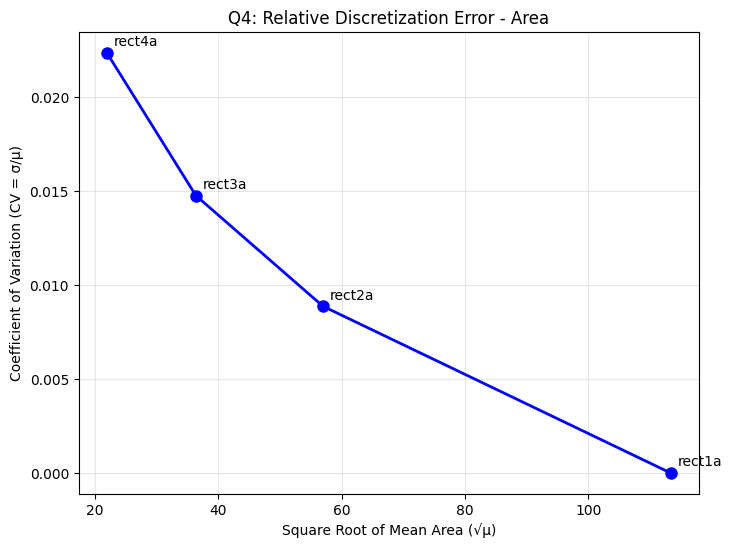

In [38]:
sqrt_mean_area = []
cv_area = []

for i in range(4):
    sqrt_val = np.sqrt(results_A['area']['means'][i])
    cv_val = results_A['area']['stds'][i] / results_A['area']['means'][i]
    sqrt_mean_area.append(sqrt_val)
    cv_area.append(cv_val)

plt.figure(figsize=(8,6))
plt.plot(sqrt_mean_area, cv_area, 'bo-', linewidth=2, markersize=8)
for i in range(4):
    plt.annotate(f'rect{i+1}a', (sqrt_mean_area[i], cv_area[i]), 
                 xytext=(5,5), textcoords='offset points', fontsize=10)
plt.xlabel('Square Root of Mean Area (√μ)')
plt.ylabel('Coefficient of Variation (CV = σ/μ)')
plt.title('Q4: Relative Discretization Error - Area')
plt.grid(True, alpha=0.3)
plt.show()

### Q5: Graph for relative discretization error (perimeter)

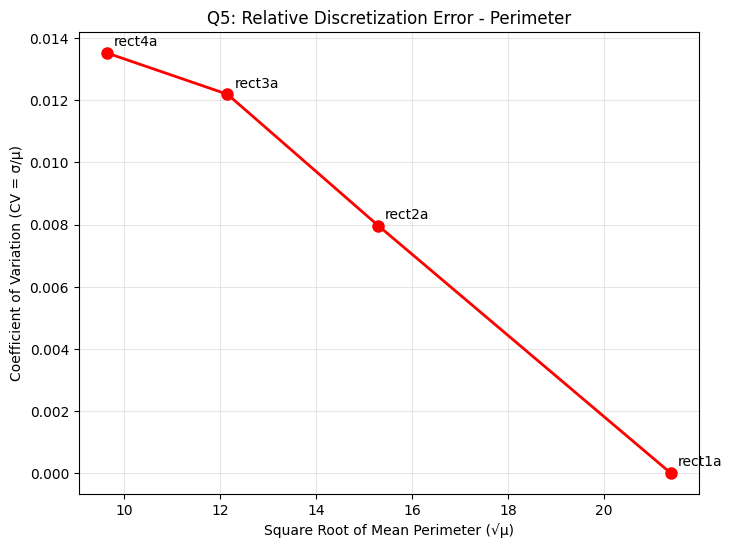

In [39]:
sqrt_mean_perim = []
cv_perim = []

for i in range(4):
    sqrt_val = np.sqrt(results_A['perimeter']['means'][i])
    cv_val = results_A['perimeter']['stds'][i] / results_A['perimeter']['means'][i]
    sqrt_mean_perim.append(sqrt_val)
    cv_perim.append(cv_val)

plt.figure(figsize=(8,6))
plt.plot(sqrt_mean_perim, cv_perim, 'ro-', linewidth=2, markersize=8)
for i in range(4):
    plt.annotate(f'rect{i+1}a', (sqrt_mean_perim[i], cv_perim[i]), 
                 xytext=(5,5), textcoords='offset points', fontsize=10)
plt.xlabel('Square Root of Mean Perimeter (√μ)')
plt.ylabel('Coefficient of Variation (CV = σ/μ)')
plt.title('Q5: Relative Discretization Error - Perimeter')
plt.grid(True, alpha=0.3)
plt.show()

---
# Part 2.3: Noise Suppression (Series B and C)
## Questions 7-11

### Q7: Histograms for Series B and C

Series B images
Rect1b


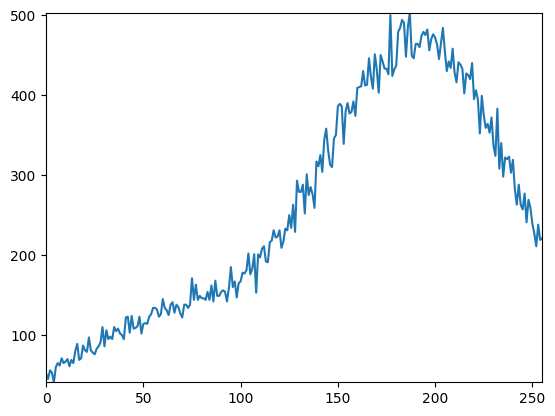

Rect2b


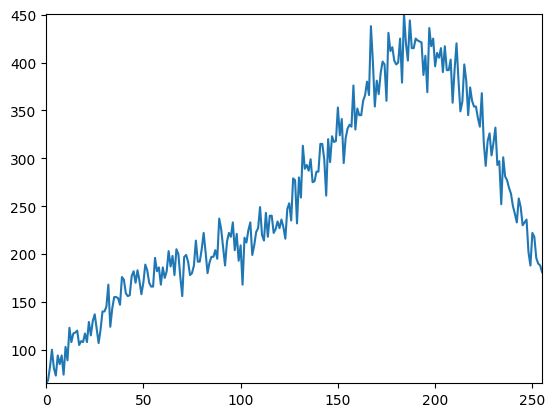

Rect3b


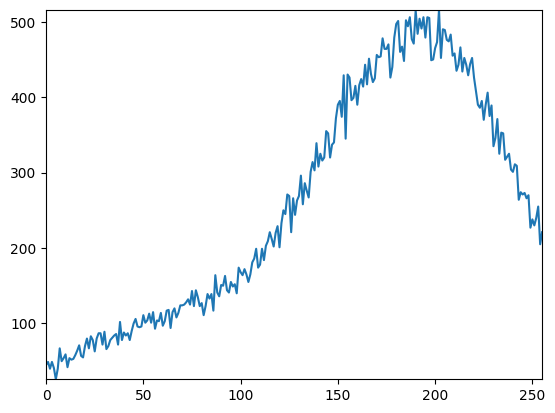

Rect4b


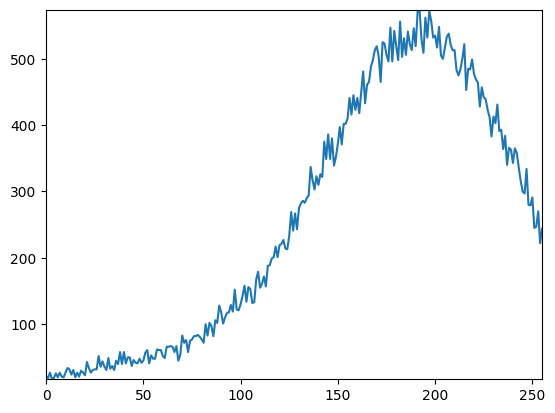

Series C images
Rect1c


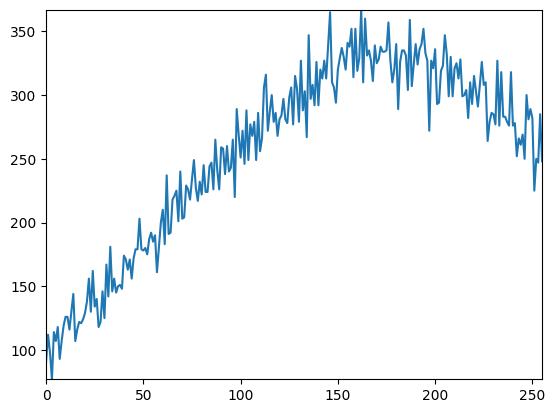

Rect2c


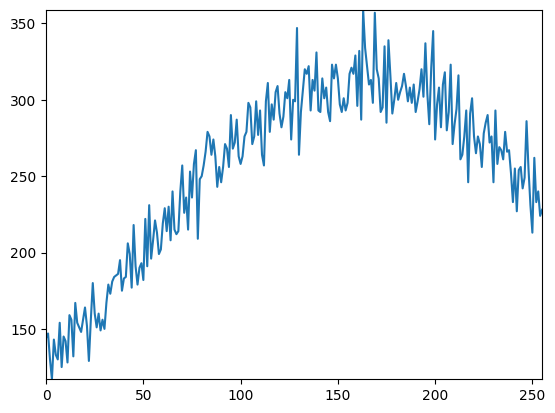

Rect3c


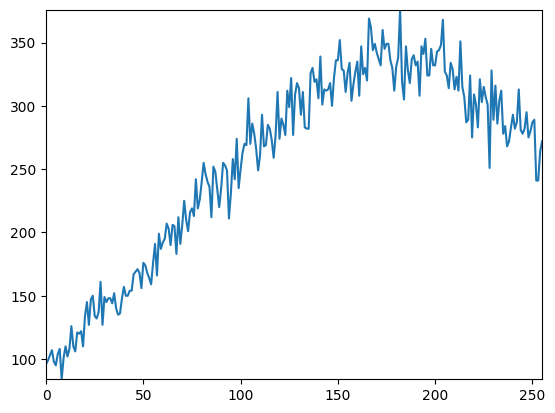

Rect4c


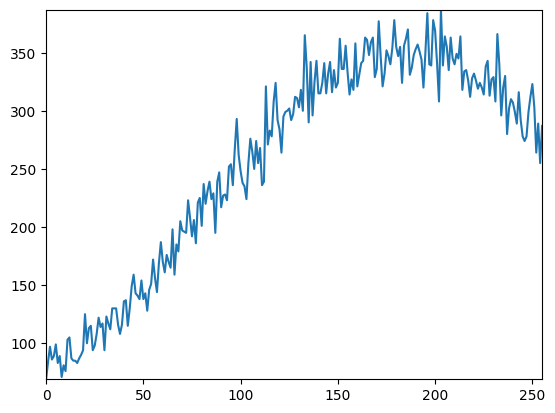

In [40]:
# Q7: Histograms for Series B

print(f"Series B images")
for i in range(1, 5):
    img = load_image('b', i)
    hist = dip.Histogram(img) 
    print(f"Rect{i}b")
    hist.Show() 

print(f"Series C images")
for i in range(1, 5):
    img = load_image('c', i)
    hist = dip.Histogram(img) 
    print(f"Rect{i}c")
    hist.Show() 

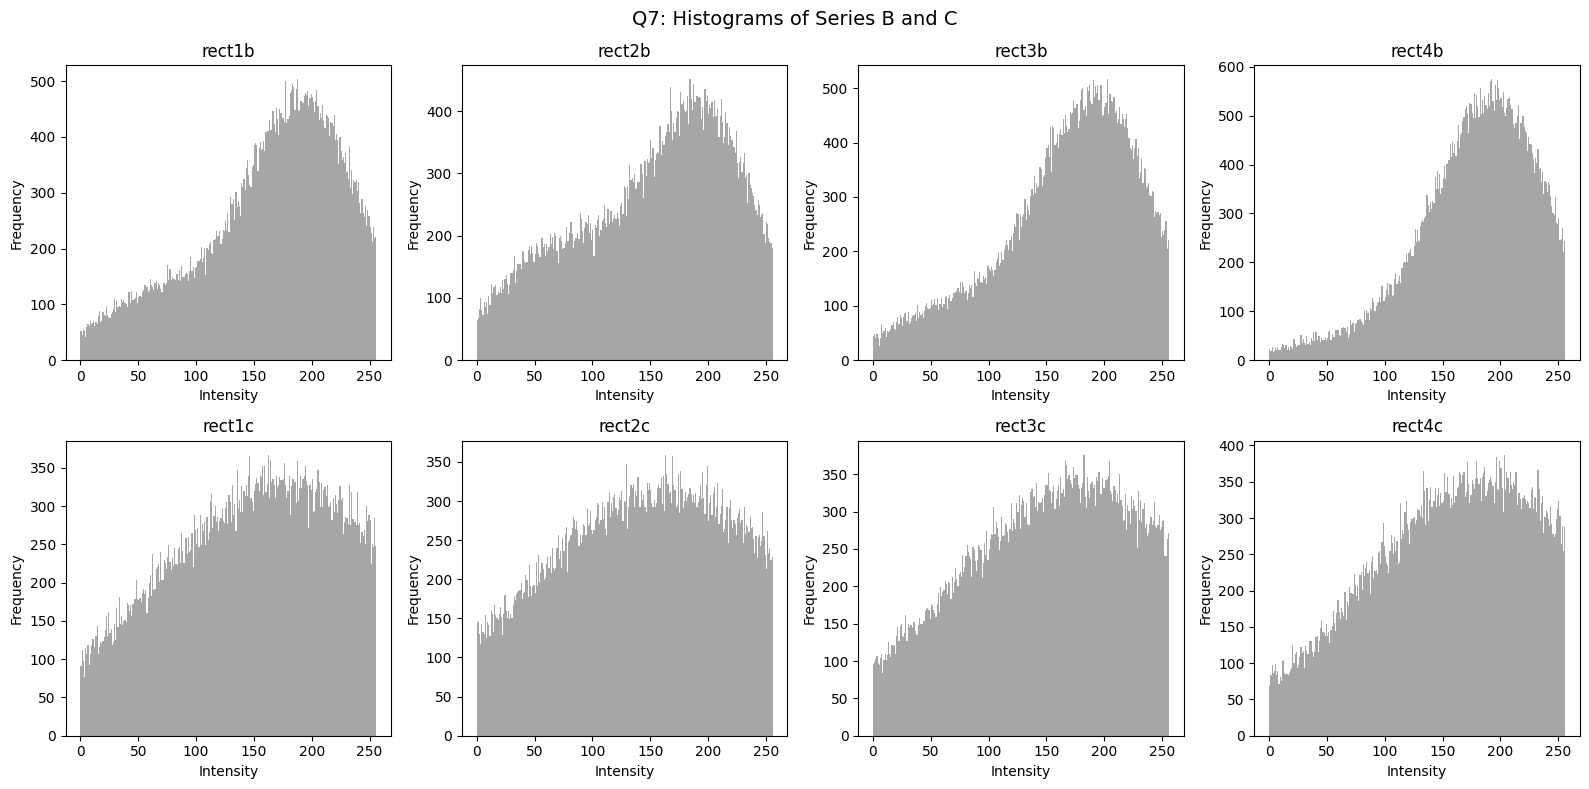

In [41]:
# Extra code (visual in report)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(1, 5):
    img_b = load_image('b', i)
    axes[0, i-1].hist(np.array(img_b).flatten(), bins=256, range=(0,256), color='gray', alpha=0.7)
    axes[0, i-1].set_title(f'rect{i}b')
    axes[0, i-1].set_xlabel('Intensity')
    axes[0, i-1].set_ylabel('Frequency')
    
    img_c = load_image('c', i)
    axes[1, i-1].hist(np.array(img_c).flatten(), bins=256, range=(0,256), color='gray', alpha=0.7)
    axes[1, i-1].set_title(f'rect{i}c')
    axes[1, i-1].set_xlabel('Intensity')
    axes[1, i-1].set_ylabel('Frequency')

plt.suptitle('Q7: Histograms of Series B and C', fontsize=14)
plt.tight_layout()
plt.show()

### Q8: Noise suppression


rect1b:
  Median k=3


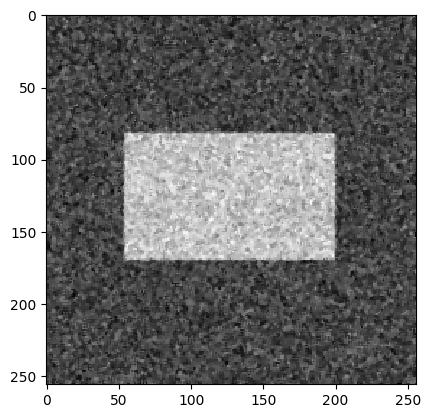

  Median k=7


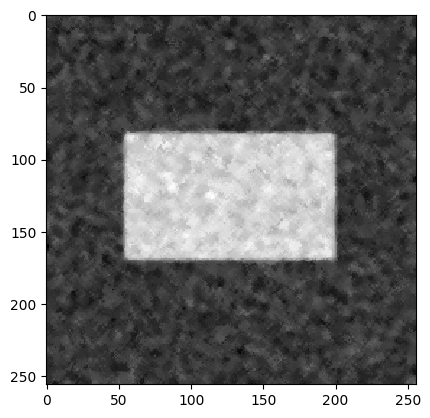

  Gaussian k=3


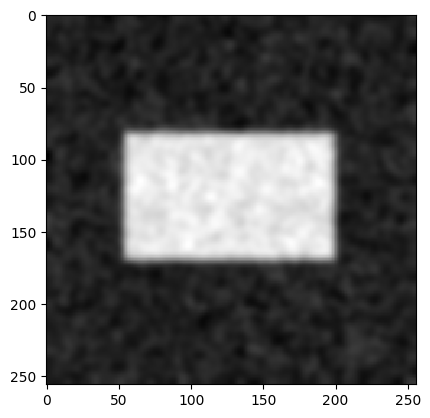

  Gaussian k=5


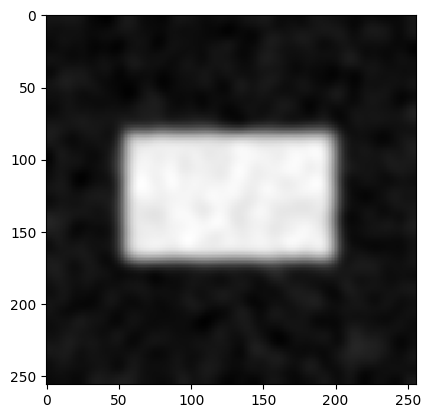

  Kuwahara k=3


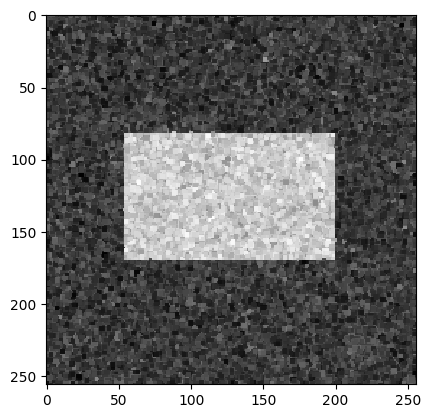

  Kuwahara k=5


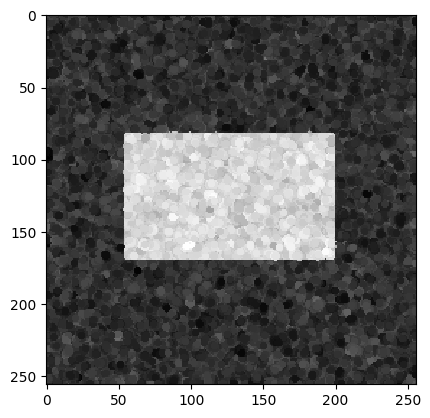


rect2b:
  Median k=3


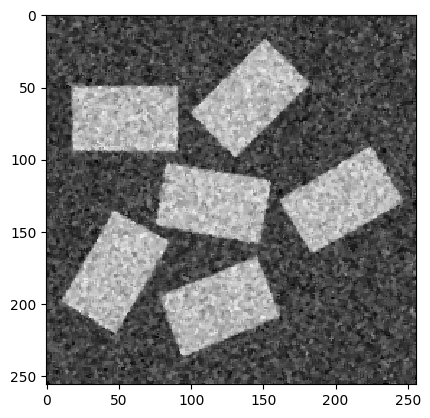

  Median k=7


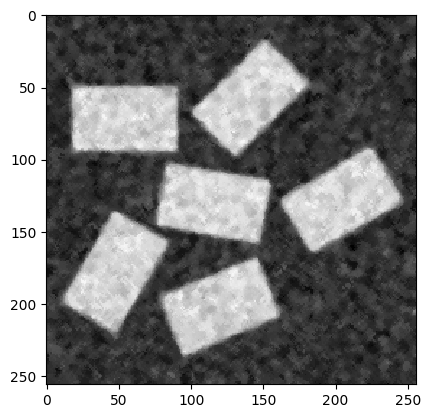

  Gaussian k=3


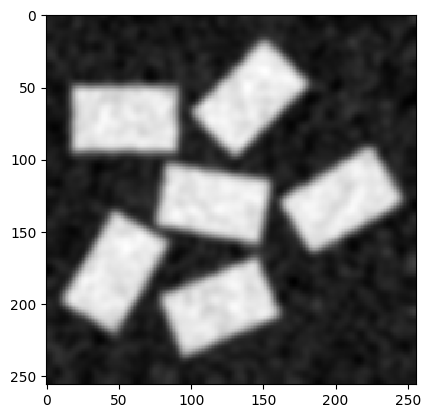

  Gaussian k=5


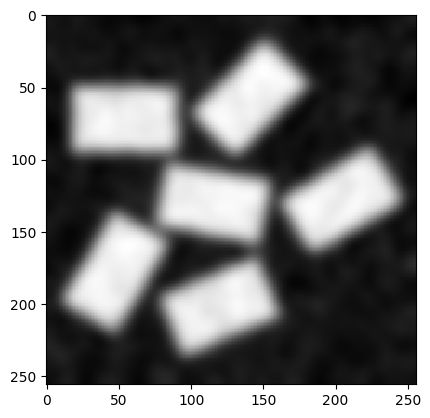

  Kuwahara k=3


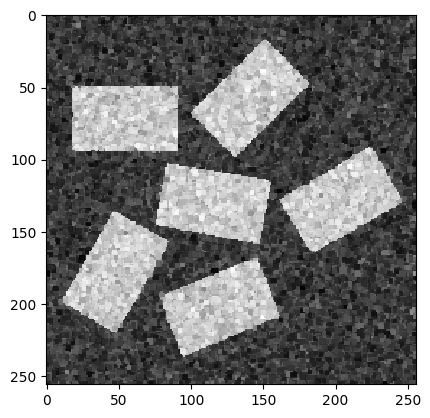

  Kuwahara k=5


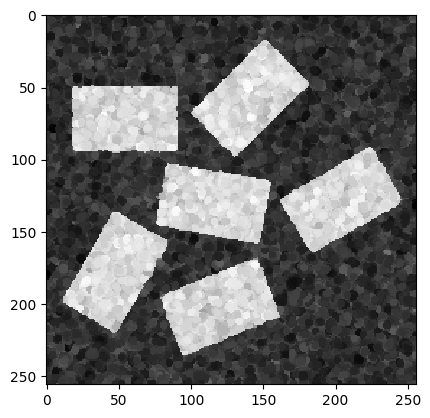


rect3b:
  Median k=3


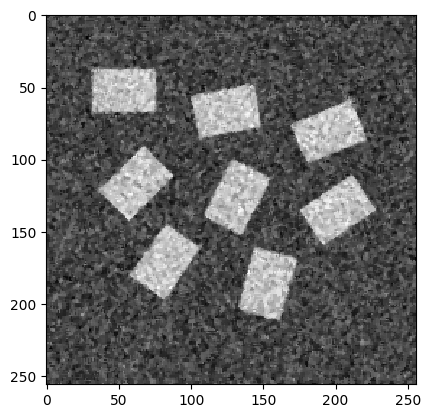

  Median k=7


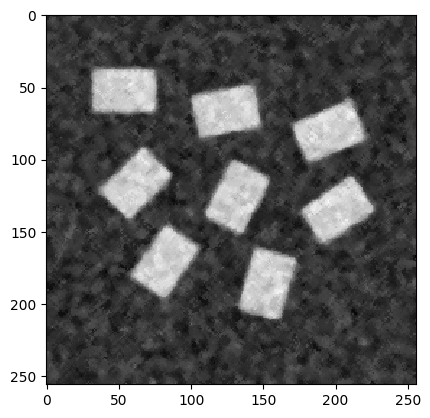

  Gaussian k=3


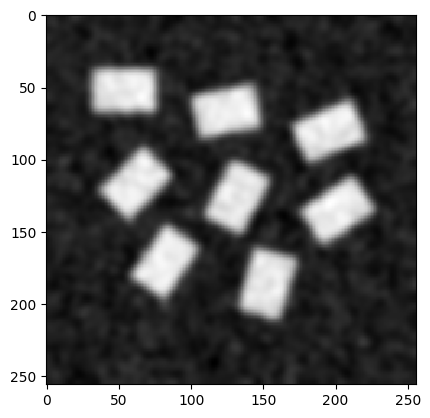

  Gaussian k=5


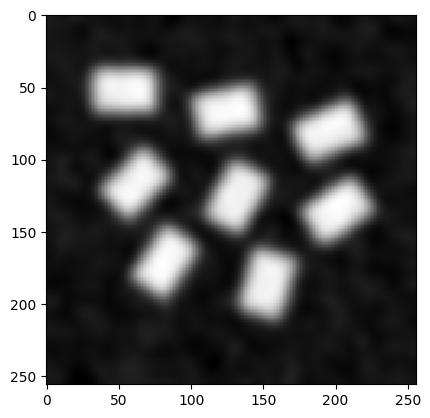

  Kuwahara k=3


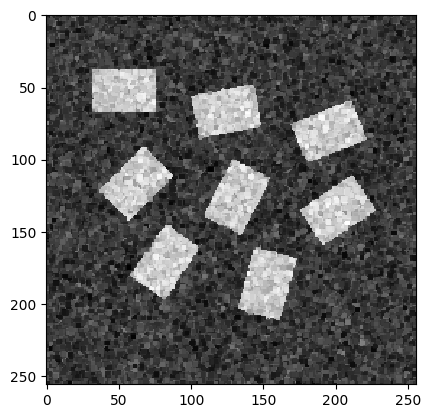

  Kuwahara k=5


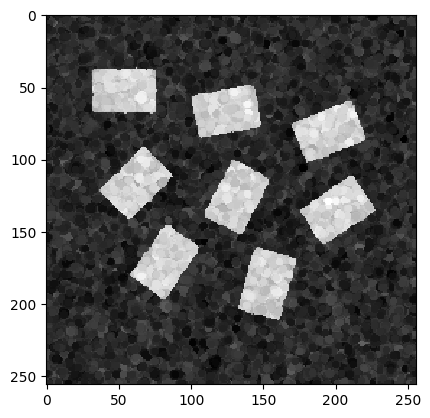


rect4b:
  Median k=3


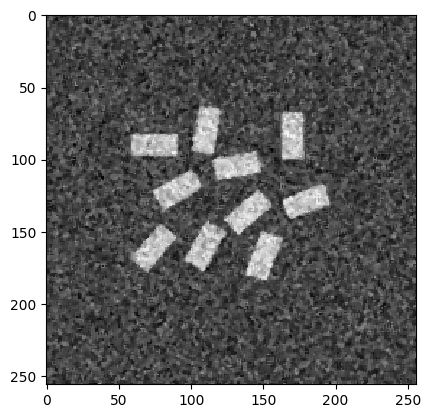

  Median k=7


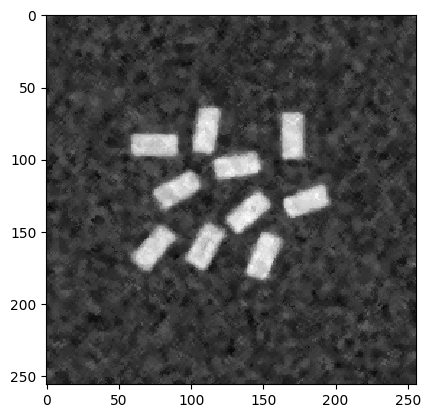

  Gaussian k=3


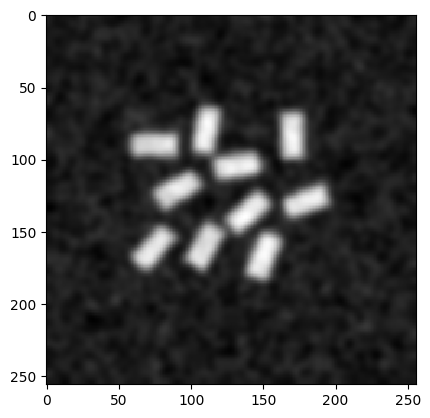

  Gaussian k=5


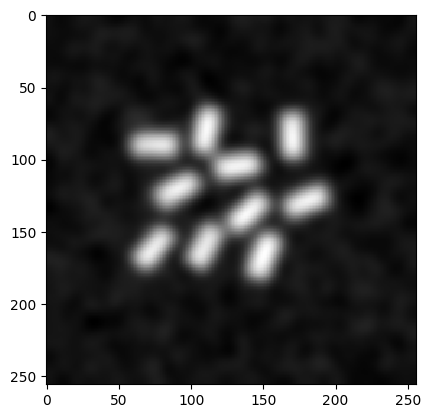

  Kuwahara k=3


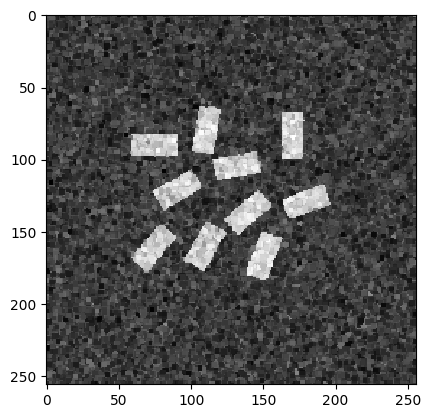

  Kuwahara k=5


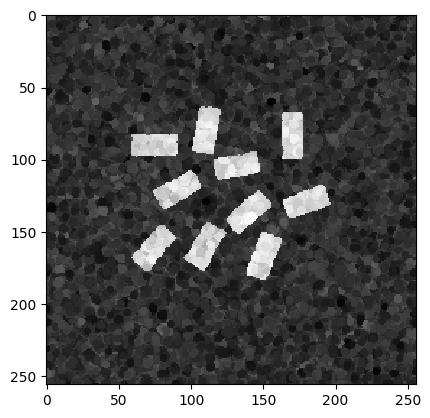


rect1c:
  Median k=3


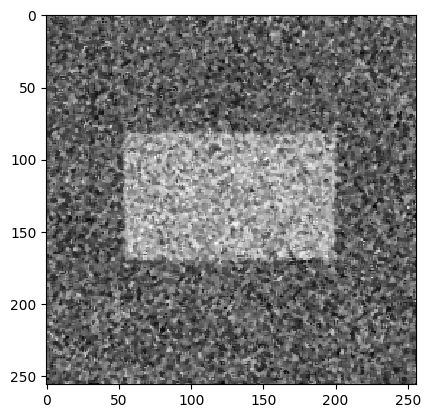

  Median k=7


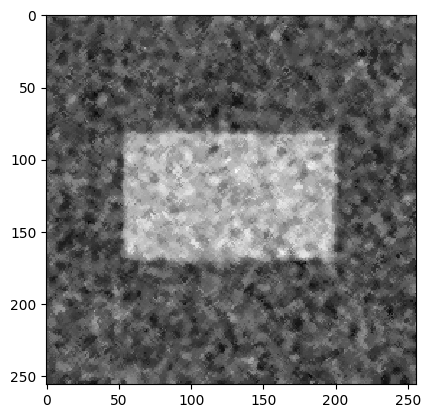

  Gaussian k=3


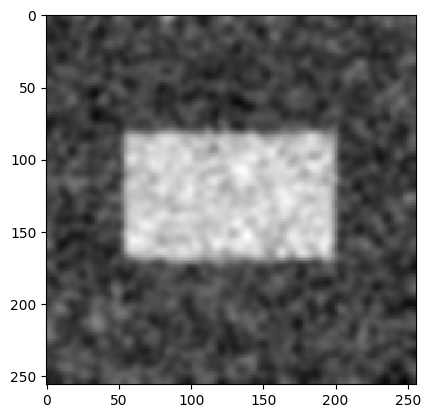

  Gaussian k=5


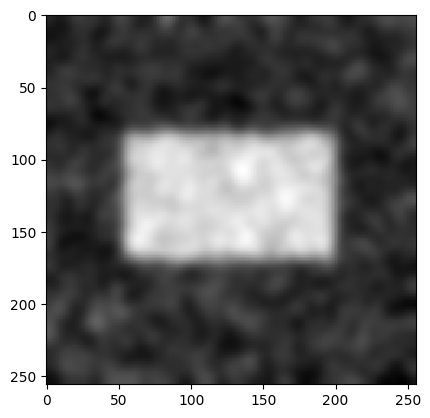

  Kuwahara k=3


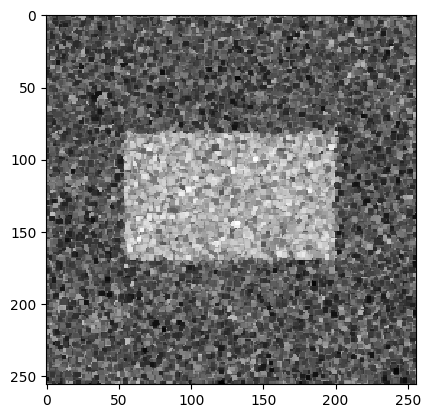

  Kuwahara k=5


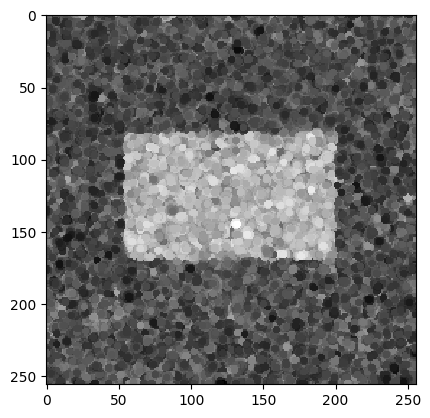


rect2c:
  Median k=3


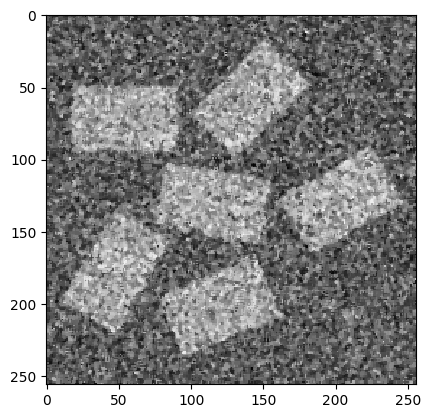

  Median k=7


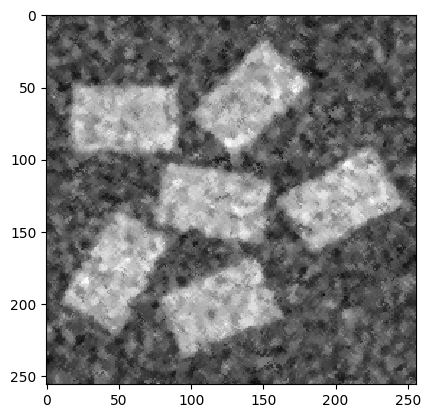

  Gaussian k=3


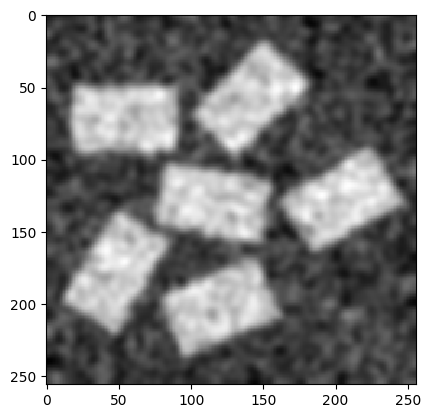

  Gaussian k=5


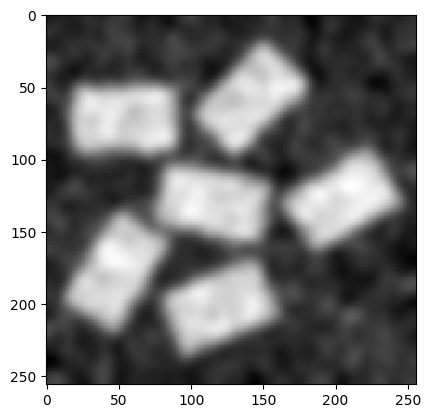

  Kuwahara k=3


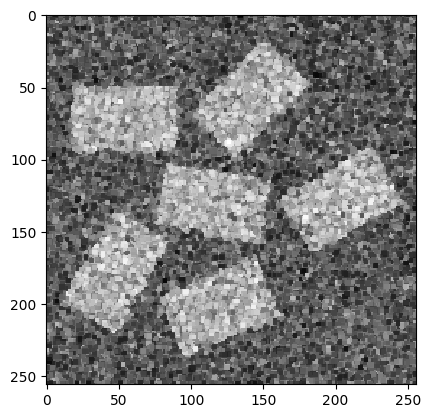

  Kuwahara k=5


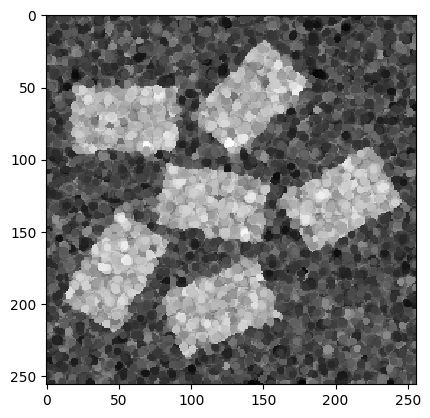


rect3c:
  Median k=3


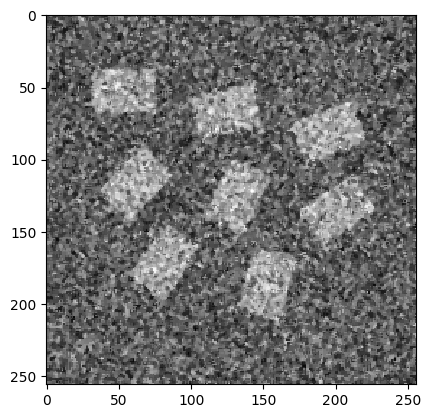

  Median k=7


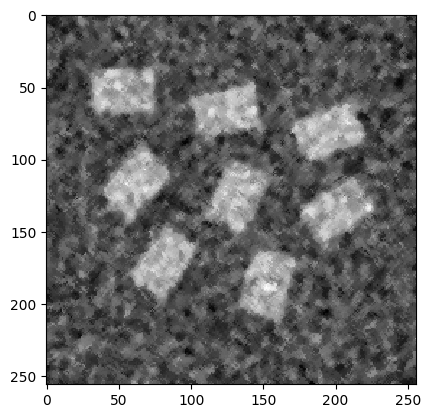

  Gaussian k=3


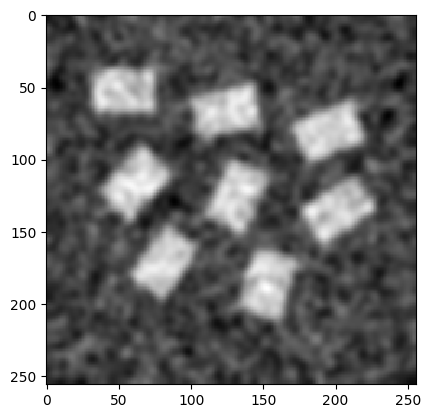

  Gaussian k=5


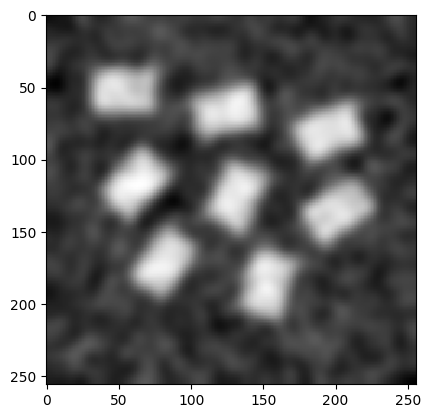

  Kuwahara k=3


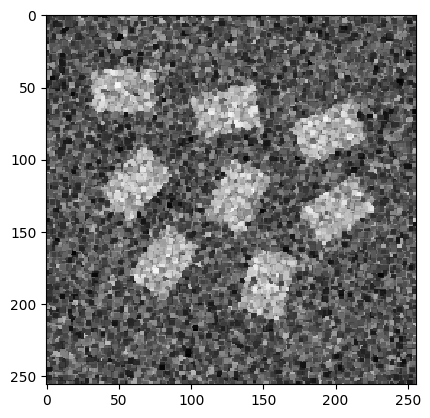

  Kuwahara k=5


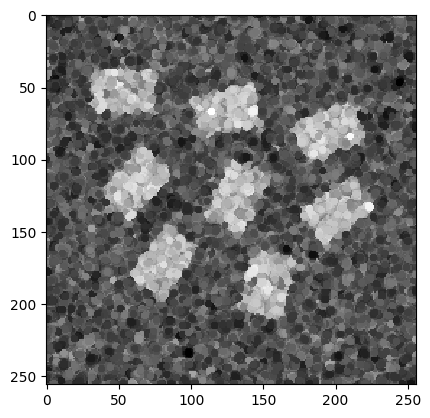


rect4c:
  Median k=3


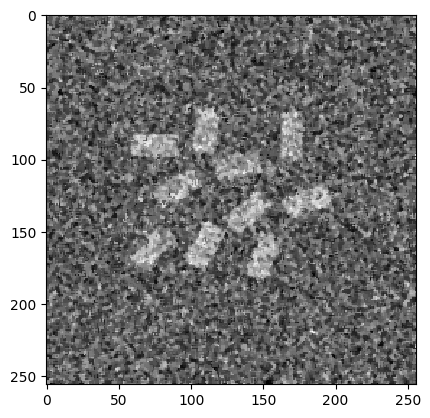

  Median k=7


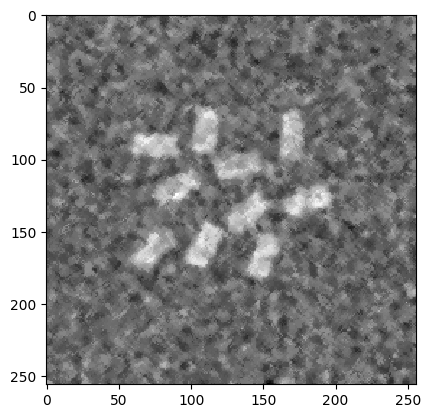

  Gaussian k=3


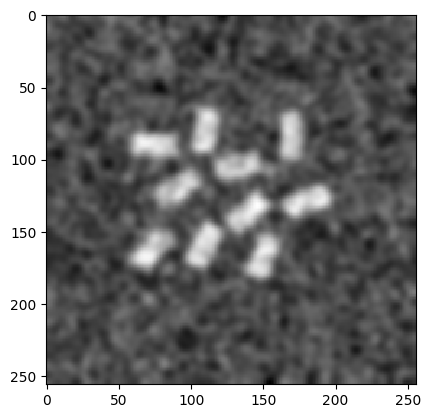

  Gaussian k=5


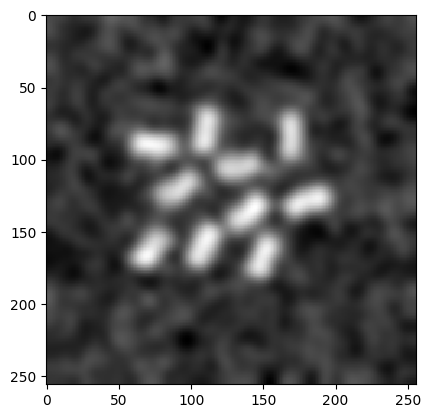

  Kuwahara k=3


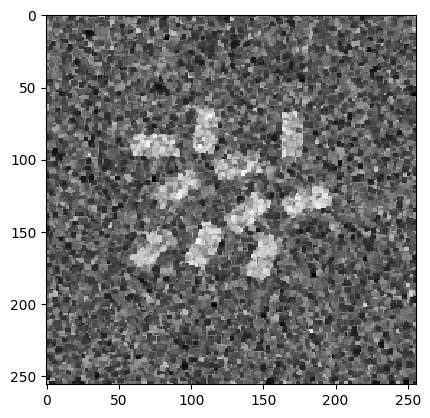

  Kuwahara k=5


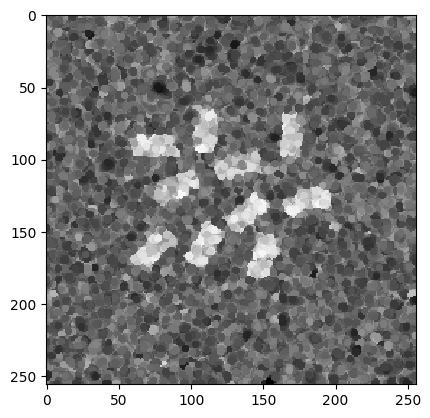

In [42]:
# Define filters and their parameters
filters_config = {
    'Median': {'func': dip.MedianFilter, 'params': [3, 7], 'param_name': 'kernel'},
    'Gaussian': {'func': dip.Gauss, 'params': [3, 5], 'param_name': 'sigmas'},
    'Kuwahara': {'func': dip.Kuwahara, 'params': [3, 5], 'param_name': 'kernel'}
}

filtered_images = {'b': {}, 'c': {}}

for series in ['b', 'c']:
    
    for i in range(1, 5):
        img = load_image(series, i)
        img_inv = 255 - img  # Invert once
        img_key = f'rect{i}{series}'
        filtered_images[series][img_key] = {}
        
        print(f"\n{img_key}:")
        
        for filter_name, filter_info in filters_config.items():
            filter_func = filter_info['func']
            param_name = filter_info['param_name']
            params = filter_info['params']
            
            # Apply filter with both parameter values
            for param in params:
                if param_name == 'kernel':
                    filtered = filter_func(img_inv, kernel=param)
                else:  # sigmas
                    filtered = filter_func(img_inv, sigmas=[param])
                
                # Store for later use
                storage_name = f"{filter_name}_k{param}"
                filtered_images[series][img_key][storage_name] = filtered
                
                # Display
                print(f"  {filter_name} k={param}")
                filtered.Show()

### Q9: Repeat measurements after filtering (tables and plots)

In [43]:
def measure_image(img):
    """Returns mean_area, std_area, mean_perimeter, std_perimeter"""
    binary = dip.IsodataThreshold(img)
    label = dip.Label(binary, connectivity=2)

    msr_area = tool.Measure(label, img, ["SolidArea"])
    areas = np.array(msr_area["SolidArea"])
    mean_area = np.mean(areas)
    std_area = np.std(areas)
    
    msr_perim = tool.Measure(label, img, ["Perimeter"])
    perimeters = np.array(msr_perim["Perimeter"])
    mean_perim = np.mean(perimeters)
    std_perim = np.std(perimeters)
    no_objects = len(areas)
    
    return mean_area, std_area, mean_perim, std_perim, no_objects

In [44]:
results_q9 = {'b': {}, 'c': {}}

for series in ['b', 'c']:
    results_q9[series] = {}
    
    for i in range(1, 5):
        img_key = f'rect{i}{series}'
        results_q9[series][img_key] = {}
        
        for filter_name in filtered_images[series][img_key].keys():
            filtered_img = filtered_images[series][img_key][filter_name]
            mean_a, std_a, mean_p, std_p, no_o = measure_image(filtered_img)
            
            results_q9[series][img_key][filter_name] = {
                'mean_area': mean_a, 'std_area': std_a,
                'mean_perim': mean_p, 'std_perim': std_p,
                "no_obj": no_o
            }

for series in ['b', 'c']:

    print(f"SERIES {series.upper()}")
    print(f"{'Image':<12} {'Filter':<18} {'Mean Area':<12} {'Std Area':<12} {'Mean Perim':<12} {'Std Perim':<12} {'No. Obj':<12}")
    print("-"*100)
    
    for i in range(1, 5):
        img_key = f'rect{i}{series}'
        for filter_name in sorted(results_q9[series][img_key].keys()):
            data = results_q9[series][img_key][filter_name]
            print(f"{img_key:<12} {filter_name:<18} {data['mean_area']:<12.2f} {data['std_area']:<12.2f} "
                  f"{data['mean_perim']:<12.2f} {data['std_perim']:<12.2f} {int(data['no_obj']):<12}")
    print("-"*100)

SERIES B
Image        Filter             Mean Area    Std Area     Mean Perim   Std Perim    No. Obj     
----------------------------------------------------------------------------------------------------
rect1b       Gaussian_k3        12848.00     0.00         453.31       0.00         1           
rect1b       Gaussian_k5        12946.00     0.00         450.59       0.00         1           
rect1b       Kuwahara_k3        1075.50      3552.26      45.07        126.92       12          
rect1b       Kuwahara_k5        12870.00     0.00         465.28       0.00         1           
rect1b       Median_k3          231.14       1702.47      12.40        62.26        56          
rect1b       Median_k7          12870.00     0.00         468.57       0.00         1           
rect2b       Gaussian_k3        3260.17      30.02        226.99       1.57         6           
rect2b       Gaussian_k5        3308.00      36.86        223.99       2.38         6           
rect2b       Kuwa

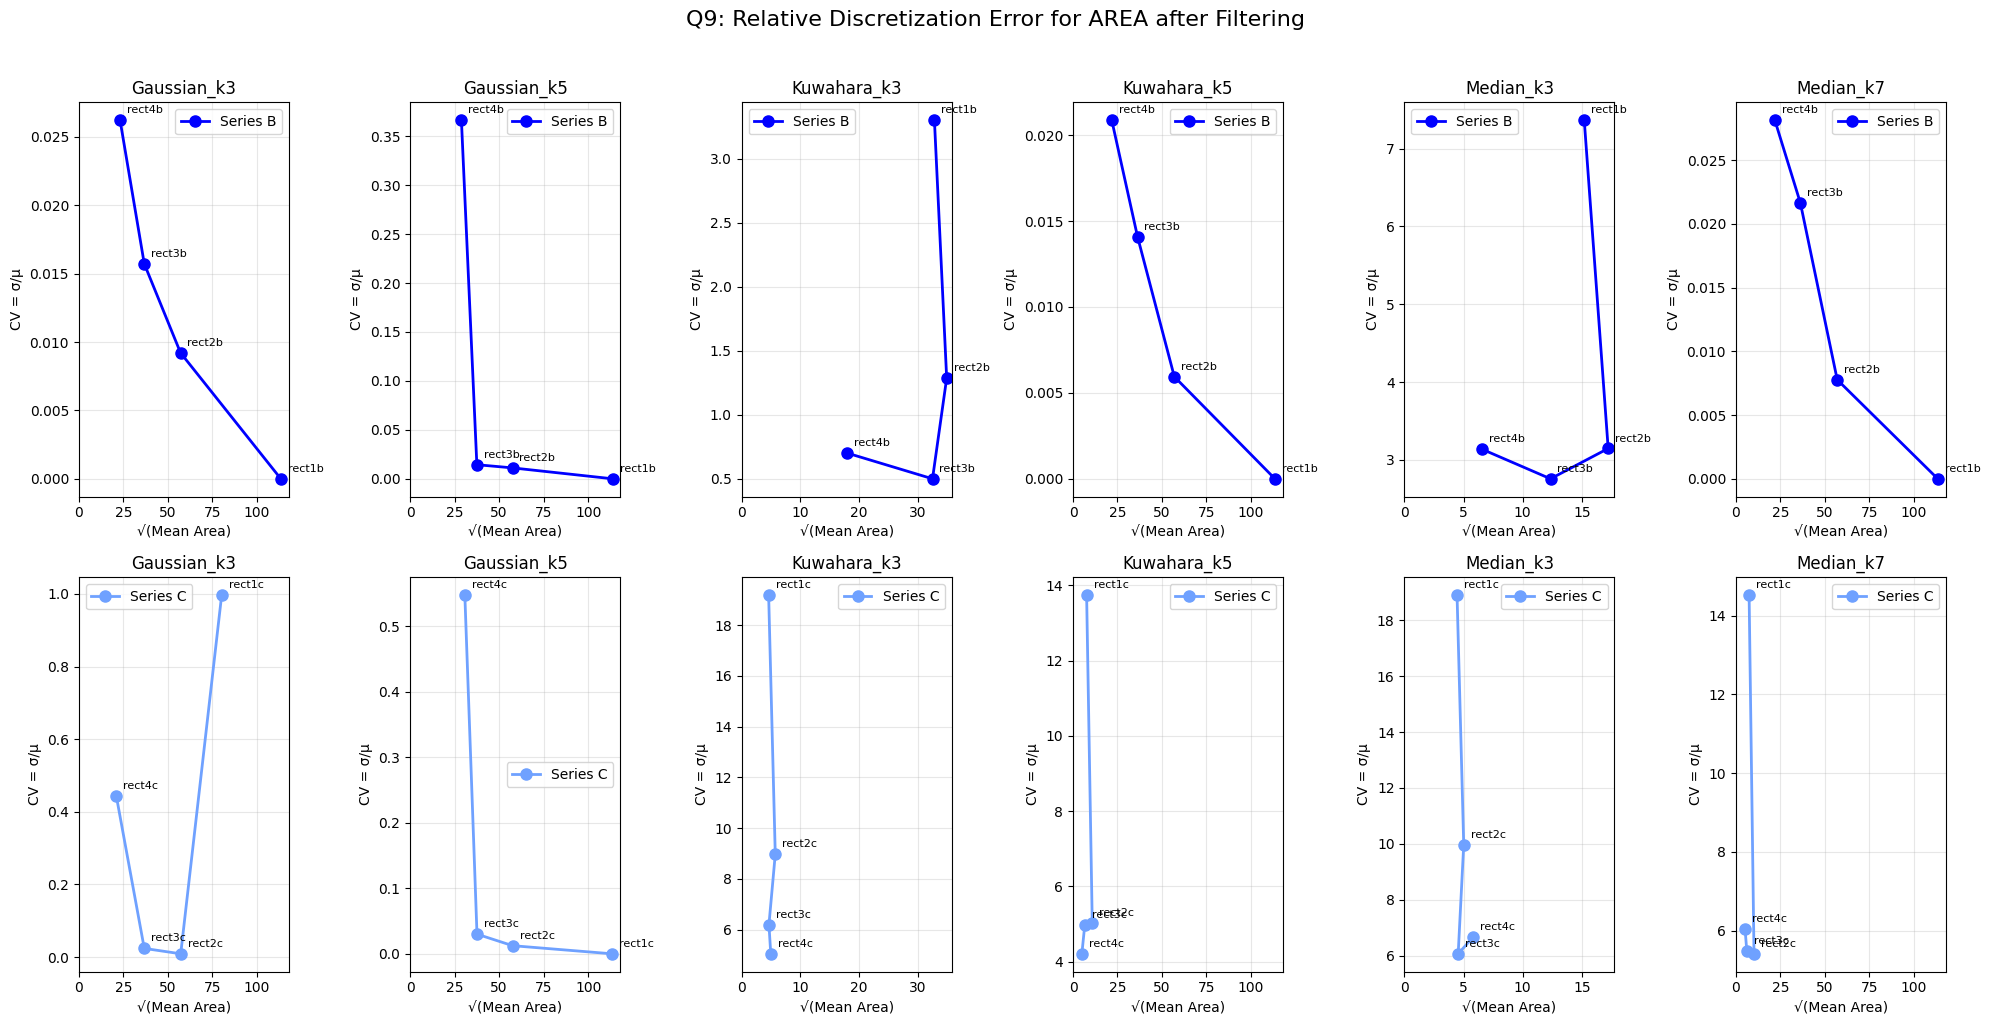

In [45]:
all_filters = set()
for series in ['b', 'c']:
    for img_key in results_q9[series]:
        all_filters.update(results_q9[series][img_key].keys())
all_filters = sorted(all_filters)

# Plot 1: AREA - Relative Discretization Error
fig, axes = plt.subplots(2, len(all_filters), figsize=(20, 10))
fig.suptitle('Q9: Relative Discretization Error for AREA after Filtering', fontsize=16, y=1.02)

for idx, filter_name in enumerate(all_filters):
    # Series B
    ax1 = axes[0, idx]
    sqrt_means_b = []
    cv_b = []
    img_names_b = []
    
    for i in range(1, 5):
        img_key = f'rect{i}b'
        if filter_name in results_q9['b'][img_key]:
            mean_a = results_q9['b'][img_key][filter_name]['mean_area']
            std_a = results_q9['b'][img_key][filter_name]['std_area']
            sqrt_means_b.append(np.sqrt(mean_a))
            cv_b.append(std_a / mean_a if mean_a > 0 else 0)
            img_names_b.append(f'rect{i}b')
    
    ax1.plot(sqrt_means_b, cv_b, 'bo-', linewidth=2, markersize=8, label='Series B')
    for j, name in enumerate(img_names_b):
        ax1.annotate(name, (sqrt_means_b[j], cv_b[j]), xytext=(5,5), 
                    textcoords='offset points', fontsize=8)
    ax1.set_xlabel('√(Mean Area)')
    ax1.set_ylabel('CV = σ/μ')
    ax1.set_title(f'{filter_name}')
    ax1.set_xlim([0, ax1.get_xlim()[1]])
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Series C
    ax2 = axes[1, idx]
    sqrt_means_c = []
    cv_c = []
    img_names_c = []
    
    for i in range(1, 5):
        img_key = f'rect{i}c'
        if filter_name in results_q9['c'][img_key]:
            mean_a = results_q9['c'][img_key][filter_name]['mean_area']
            std_a = results_q9['c'][img_key][filter_name]['std_area']
            sqrt_means_c.append(np.sqrt(mean_a))
            cv_c.append(std_a / mean_a if mean_a > 0 else 0)
            img_names_c.append(f'rect{i}c')
    
    ax2.plot(sqrt_means_c, cv_c,  '#6fa1ff', marker='o',linewidth=2, markersize=8, label='Series C')
    for j, name in enumerate(img_names_c):
        ax2.annotate(name, (sqrt_means_c[j], cv_c[j]), xytext=(5,5), 
                    textcoords='offset points', fontsize=8)
    ax2.set_xlabel('√(Mean Area)')
    ax2.set_xlim([0, ax1.get_xlim()[1]])
    ax2.set_ylabel('CV = σ/μ')
    ax2.set_title(f'{filter_name}')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.tight_layout()
plt.show()

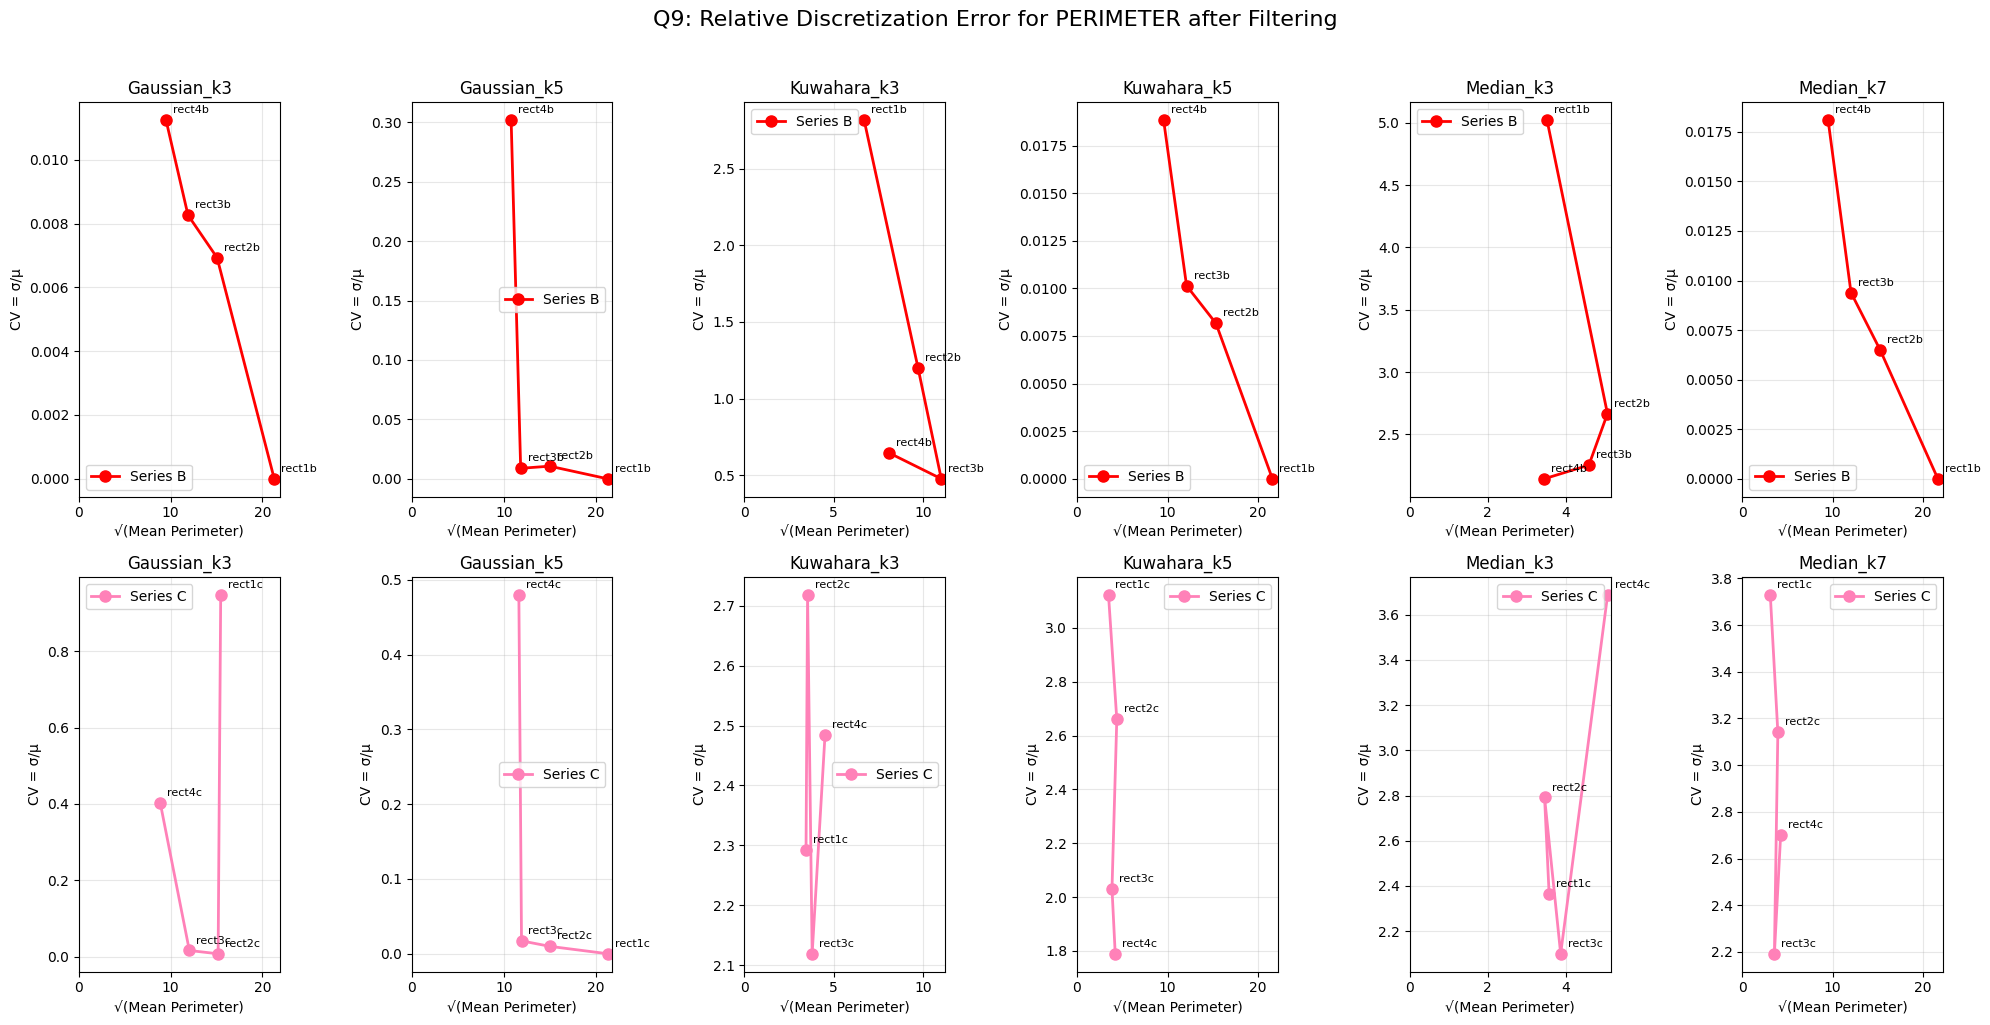

In [46]:
fig, axes = plt.subplots(2, len(all_filters), figsize=(20, 10))
fig.suptitle('Q9: Relative Discretization Error for PERIMETER after Filtering', fontsize=16, y=1.02)

for idx, filter_name in enumerate(all_filters):
    # Series B
    ax1 = axes[0, idx]
    sqrt_means_b = []
    cv_b = []
    img_names_b = []
    
    for i in range(1, 5):
        img_key = f'rect{i}b'
        if filter_name in results_q9['b'][img_key]:
            mean_p = results_q9['b'][img_key][filter_name]['mean_perim']
            std_p = results_q9['b'][img_key][filter_name]['std_perim']
            sqrt_means_b.append(np.sqrt(mean_p))
            cv_b.append(std_p / mean_p if mean_p > 0 else 0)
            img_names_b.append(f'rect{i}b')
    
    ax1.plot(sqrt_means_b, cv_b, 'ro-', linewidth=2, markersize=8, label='Series B')
    for j, name in enumerate(img_names_b):
        ax1.annotate(name, (sqrt_means_b[j], cv_b[j]), xytext=(5,5), 
                    textcoords='offset points', fontsize=8)
    ax1.set_xlabel('√(Mean Perimeter)')
    ax1.set_ylabel('CV = σ/μ')
    ax1.set_xlim([0, ax1.get_xlim()[1]])
    ax1.set_title(f'{filter_name}')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Series C
    ax2 = axes[1, idx]
    sqrt_means_c = []
    cv_c = []
    img_names_c = []
    
    for i in range(1, 5):
        img_key = f'rect{i}c'
        if filter_name in results_q9['c'][img_key]:
            mean_p = results_q9['c'][img_key][filter_name]['mean_perim']
            std_p = results_q9['c'][img_key][filter_name]['std_perim']
            sqrt_means_c.append(np.sqrt(mean_p))
            cv_c.append(std_p / mean_p if mean_p > 0 else 0)
            img_names_c.append(f'rect{i}c')
    
    ax2.plot(sqrt_means_c, cv_c, color="#ff81b8", marker='o', linewidth=2, markersize=8, label='Series C')
    for j, name in enumerate(img_names_c):
        ax2.annotate(name, (sqrt_means_c[j], cv_c[j]), xytext=(5,5), 
                    textcoords='offset points', fontsize=8)
    ax2.set_xlabel('√(Mean Perimeter)')
    ax2.set_ylabel('CV = σ/μ')
    ax2.set_xlim([0, ax1.get_xlim()[1]])
    ax2.set_title(f'{filter_name}')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.tight_layout()
plt.show()

---
# Part 2.4: Signal-to-Noise Ratio (SNR)
## Questions 12-13

### Q12: Compute SNR for all images (original and filtered)

In [47]:
def compute_snr(image):
    """Compute Signal-to-Noise Ratio = mean / standard deviation"""
    img_array = np.array(image).flatten().astype(np.float64)
    mu = np.mean(img_array)
    sigma = np.std(img_array)
    
    if sigma == 0:
        return np.inf
    
    return mu / sigma


filters_to_test = [
    {'name': 'Median_k3', 'filter': 'median', 'kernel': 3},
    {'name': 'Median_k7', 'filter': 'median', 'kernel': 7},
    {'name': 'Gauss_s3', 'filter': 'gauss', 'sigmas': [3]},
    {'name': 'Gauss_s5', 'filter': 'gauss', 'sigmas': [5]},
    {'name': 'Kuwahara_k3', 'filter': 'kuwa', 'kernel': 3},
    {'name': 'Kuwahara_k5', 'filter': 'kuwa', 'kernel': 5}
]

snr_results = {
    'A': {'original': []},
    'B': {'original': [], 'filtered': {}},
    'C': {'original': [], 'filtered': {}}
}


for filter_config in filters_to_test:
    if filter_config['name'] != 'Original (No Filter)':
        snr_results['B']['filtered'][filter_config['name']] = []
        snr_results['C']['filtered'][filter_config['name']] = []



In [48]:

# PART 1: Compute SNR for original Series A, B, C (no filtering)
for series in ['A', 'B', 'C']:
    series_lower = series.lower()
    
    for i in range(1, 5):
        img = load_image(series_lower, i)
        snr = compute_snr(img)
        snr_results[series]['original'].append(snr)

# PART 2: Apply filters to Series B and C and compute SNR
filtered_images = {'b': {}, 'c': {}}

for series in ['b', 'c']:
    
    for i in range(1, 5):
        img = load_image(series, i)
        img_key = f'rect{i}{series}'
        filtered_images[series][img_key] = {}
        
        for filter_config in filters_to_test:
            filter_name = filter_config['name']
            
            if filter_name == 'Original (No Filter)':
                continue
                
            filter_type = filter_config['filter']
            
            # Apply filter based on type
            if filter_type == 'median':
                kernel = filter_config['kernel']
                filtered = dip.MedianFilter(img, kernel=kernel)
            elif filter_type == 'bilateral':
                spatial = filter_config['spatial']
                tonal = filter_config['tonal']
                filtered = dip.BilateralFilter(img, spatialSigmas=spatial, tonalSigma=tonal)
            elif filter_type == 'gauss':
                sigmas = filter_config['sigmas']
                filtered = dip.Gauss(img, sigmas=sigmas)
            elif filter_type == 'kuwa':
                sigmas = filter_config['kernel']
                filtered = dip.Kuwahara(img, kernel=kernel)    
            
            filtered_images[series][img_key][filter_name] = filtered
            
            # Compute SNR for filtered image
            snr = compute_snr(filtered)
            
            # Store results
            if series == 'b':
                snr_results['B']['filtered'][filter_name].append(snr)
            else:
                snr_results['C']['filtered'][filter_name].append(snr)
            



In [49]:

print("\nORIGINAL IMAGES (No Filter)")
print(f"{'Image':<15} {'Series A SNR':<15} {'Series B SNR':<15} {'Series C SNR':<15}")

for i in range(4):
    snr_a = snr_results['A']['original'][i]
    snr_b = snr_results['B']['original'][i]
    snr_c = snr_results['C']['original'][i]
    print(f"rect{i+1:<10} {snr_a:<15.4f} {snr_b:<15.4f} {snr_c:<15.4f}")

# Mean SNR for original series
mean_snr_a = np.mean(snr_results['A']['original'])
mean_snr_b = np.mean(snr_results['B']['original'])
mean_snr_c = np.mean(snr_results['C']['original'])
print("-" * 60)
print(f"{'MEAN':<15} {mean_snr_a:<15.4f} {mean_snr_b:<15.4f} {mean_snr_c:<15.4f}")

# Table for Filtered Series B
print("\n")
print("FILTERED SERIES B (Noisy - Moderate Noise)")
print(f"{'Image':<15}", end="")
for filter_config in filters_to_test:
    if filter_config['name'] != 'Original (No Filter)':
        print(f"{filter_config['name'][:18]:<18}", end="")
print()
print("-" * (15 + 18 * 6))

for i in range(4):
    print(f"rect{i+1}b{' ':<9}", end="")
    for filter_config in filters_to_test:
        if filter_config['name'] != 'Original (No Filter)':
            snr_val = snr_results['B']['filtered'][filter_config['name']][i]
            print(f"{snr_val:<18.4f}", end="")
    print()

# Mean SNR for filtered Series B
print("-" * (15 + 18 * 6))
print(f"{'MEAN':<15}", end="")
for filter_config in filters_to_test:
    if filter_config['name'] != 'Original (No Filter)':
        mean_snr = np.mean(snr_results['B']['filtered'][filter_config['name']])
        print(f"{mean_snr:<18.4f}", end="")
print()

# Table for Filtered Series C
print("\n" )
print("FILTERED SERIES C (Noisy - High Noise)")
print(f"{'Image':<15}", end="")
for filter_config in filters_to_test:
    if filter_config['name'] != 'Original (No Filter)':
        print(f"{filter_config['name'][:18]:<18}", end="")
print()
print("-" * (15 + 18 * 6))

for i in range(4):
    print(f"rect{i+1}c{' ':<9}", end="")
    for filter_config in filters_to_test:
        if filter_config['name'] != 'Original (No Filter)':
            snr_val = snr_results['C']['filtered'][filter_config['name']][i]
            print(f"{snr_val:<18.4f}", end="")
    print()

# Mean SNR for filtered Series C
print("-" * (15 + 18 * 6))
print(f"{'MEAN':<15}", end="")
for filter_config in filters_to_test:
    if filter_config['name'] != 'Original (No Filter)':
        mean_snr = np.mean(snr_results['C']['filtered'][filter_config['name']])
        print(f"{mean_snr:<18.4f}", end="")
print()


ORIGINAL IMAGES (No Filter)
Image           Series A SNR    Series B SNR    Series C SNR   
rect1          3.2845          2.6590          2.1626         
rect2          2.6312          2.3021          2.0429         
rect3          3.6357          2.8273          2.1987         
rect4          5.4589          3.4282          2.3291         
------------------------------------------------------------
MEAN            3.7526          2.8042          2.1833         


FILTERED SERIES B (Noisy - Moderate Noise)
Image          Median_k3         Median_k7         Gauss_s3          Gauss_s5          Kuwahara_k3       Kuwahara_k5       
---------------------------------------------------------------------------------------------------------------------------
rect1b         3.3152            3.5230            3.8546            3.9725            3.5129            3.5129            
rect2b         2.7640            2.9389            3.2958            3.5313            2.8627            2.8627  

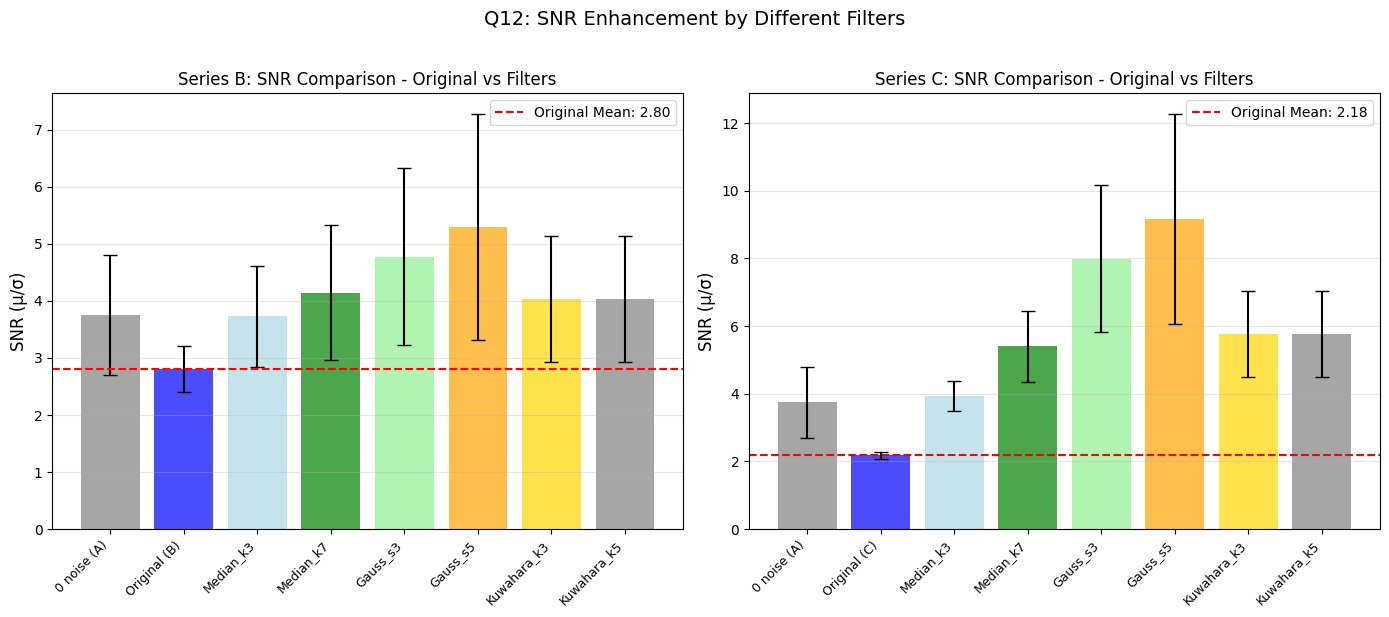

In [50]:
# Visual comparison of all filters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Series B
ax = axes[0]
filter_names = []
filter_means = []
filter_stds = []

for filter_config in filters_to_test:
    if filter_config['name'] != 'Original (No Filter)':
        filter_names.append(filter_config['name'])
        mean_val = np.mean(snr_results['B']['filtered'][filter_config['name']])
        std_val = np.std(snr_results['B']['filtered'][filter_config['name']])
        filter_means.append(mean_val)
        filter_stds.append(std_val)




filter_names.insert(0, '0 noise (A)')
filter_means.insert(0, np.mean(snr_results['A']['original']))
filter_stds.insert(0, np.std(snr_results['A']['original']))

# Add original as baseline
filter_names.insert(1, 'Original (B)')
filter_means.insert(1, np.mean(snr_results['B']['original']))
filter_stds.insert(1, np.std(snr_results['B']['original']))

x_pos = np.arange(len(filter_names))
bars = ax.bar(x_pos, filter_means, yerr=filter_stds, capsize=5, alpha=0.7, 
              color=['gray', 'blue', 'lightblue', 'green', 'lightgreen', 'orange', 'gold'])
ax.set_xticks(x_pos)
ax.set_xticklabels(filter_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('SNR (μ/σ)', fontsize=12)
ax.set_title('Series B: SNR Comparison - Original vs Filters', fontsize=12)
ax.axhline(y=np.mean(snr_results['B']['original']), color='red', linestyle='--', 
           label=f'Original Mean: {np.mean(snr_results["B"]["original"]):.2f}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot for Series C
ax = axes[1]
filter_names = []
filter_means = []
filter_stds = []

for filter_config in filters_to_test:
    if filter_config['name'] != 'Original (No Filter)':
        filter_names.append(filter_config['name'])
        mean_val = np.mean(snr_results['C']['filtered'][filter_config['name']])
        std_val = np.std(snr_results['C']['filtered'][filter_config['name']])
        filter_means.append(mean_val)
        filter_stds.append(std_val)

filter_names.insert(0, '0 noise (A)')
filter_means.insert(0, np.mean(snr_results['A']['original']))
filter_stds.insert(0, np.std(snr_results['A']['original']))

# Add original as baseline
filter_names.insert(1, 'Original (C)')
filter_means.insert(1, np.mean(snr_results['C']['original']))
filter_stds.insert(1, np.std(snr_results['C']['original']))

x_pos = np.arange(len(filter_names))
bars = ax.bar(x_pos, filter_means, yerr=filter_stds, capsize=5, alpha=0.7,
              color=['gray', 'blue', 'lightblue', 'green', 'lightgreen', 'orange', 'gold'])
ax.set_xticks(x_pos)
ax.set_xticklabels(filter_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('SNR (μ/σ)', fontsize=12)
ax.set_title('Series C: SNR Comparison - Original vs Filters', fontsize=12)
ax.axhline(y=np.mean(snr_results['C']['original']), color='red', linestyle='--',
           label=f'Original Mean: {np.mean(snr_results["C"]["original"]):.2f}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Q12: SNR Enhancement by Different Filters', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Q13: SNR vs log(measurement) plot

In [51]:
def get_total_measurements(img):
    """Returns total area and total perimeter (sum over all objects)"""
    img_inv = 255 - img
    binary = dip.IsodataThreshold(img_inv)
    label = dip.Label(binary, connectivity=2)
    
    msr_area = tool.Measure(label, img, ["SolidArea"])
    msr_perim = tool.Measure(label, img, ["Perimeter"])
    
    total_area = np.sum(np.array(msr_area["SolidArea"]))
    total_perim = np.sum(np.array(msr_perim["Perimeter"]))
    
    return total_area, total_perim

snr_original = {'A': [], 'B': [], 'C': []}
total_area_original = {'A': [], 'B': [], 'C': []}
total_perim_original = {'A': [], 'B': [], 'C': []}

for series in ['A', 'B', 'C']:
    series_lower = series.lower()
    for i in range(1, 5):
        img = load_image(series_lower, i)
        snr_original[series].append(snr_results[series]['original'][i-1])
        total_area, total_perim = get_total_measurements(img)
        total_area_original[series].append(total_area)
        total_perim_original[series].append(total_perim)

# Collect data for filtered images (best filters: Median_k5, Gauss_s3, Kuwahara_k5)
best_filters = ['Median_k7', 'Gauss_s3', 'Kuwahara_k5']
snr_filtered = {'b': {f: [] for f in best_filters}, 'c': {f: [] for f in best_filters}}
area_filtered = {'b': {f: [] for f in best_filters}, 'c': {f: [] for f in best_filters}}
perim_filtered = {'b': {f: [] for f in best_filters}, 'c': {f: [] for f in best_filters}}

for series in ['b', 'c']:
    for i in range(1, 5):
        img_key = f'rect{i}{series}'
        for filter_name in best_filters:
            if filter_name in filtered_images[series][img_key]:
                filtered_img = filtered_images[series][img_key][filter_name]
                snr = compute_snr(filtered_img)
                total_area, total_perim = get_total_measurements(filtered_img)
                
                if series == 'b':
                    snr_filtered['b'][filter_name].append(snr)
                    area_filtered['b'][filter_name].append(total_area)
                    perim_filtered['b'][filter_name].append(total_perim)
                else:
                    snr_filtered['c'][filter_name].append(snr)
                    area_filtered['c'][filter_name].append(total_area)
                    perim_filtered['c'][filter_name].append(total_perim)

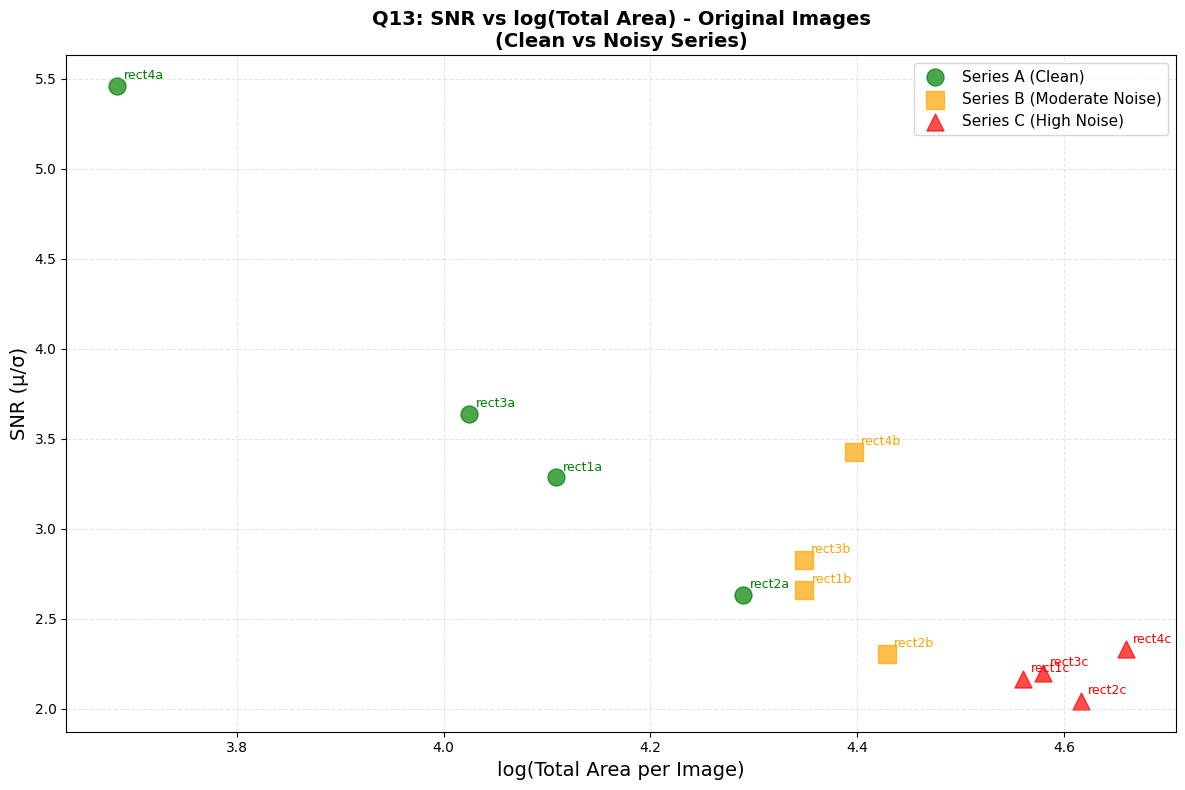

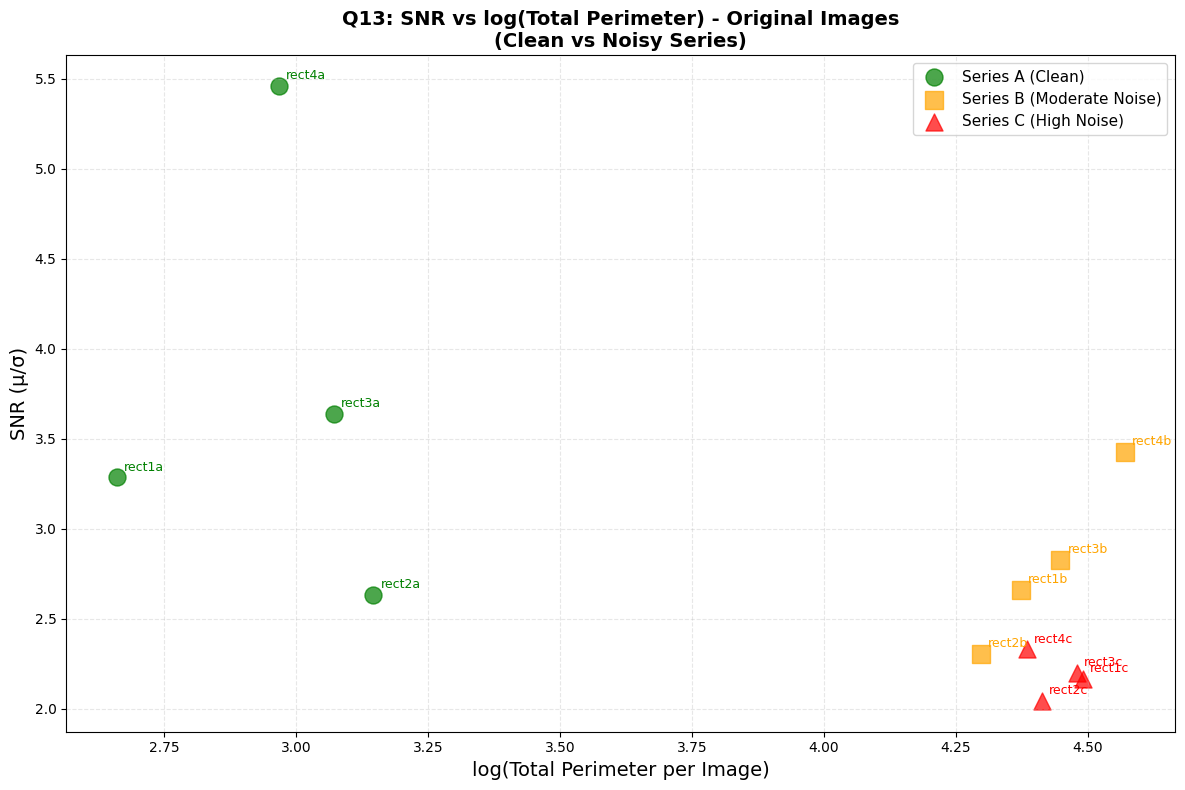

In [52]:
plt.figure(figsize=(12, 8))

colors = {'A': 'green', 'B': 'orange', 'C': 'red'}
markers = {'A': 'o', 'B': 's', 'C': '^'}
labels = {'A': 'Series A (Clean)', 'B': 'Series B (Moderate Noise)', 'C': 'Series C (High Noise)'}

for series in ['A', 'B', 'C']:
    log_area = np.log10(total_area_original[series])
    plt.scatter(log_area, snr_original[series], color=colors[series], 
                marker=markers[series], s=150, label=labels[series], alpha=0.7)
    
    # Add labels for each point
    for i in range(4):
        plt.annotate(f'rect{i+1}{series.lower()}', 
                    (log_area[i], snr_original[series][i]),
                    xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, color=colors[series])

plt.xlabel('log(Total Area per Image)', fontsize=14)
plt.ylabel('SNR (μ/σ)', fontsize=14)
plt.title('Q13: SNR vs log(Total Area) - Original Images\n(Clean vs Noisy Series)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=11)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))

for series in ['A', 'B', 'C']:
    log_perim = np.log10(total_perim_original[series])
    plt.scatter(log_perim, snr_original[series], color=colors[series], 
                marker=markers[series], s=150, label=labels[series], alpha=0.7)
    
    for i in range(4):
        plt.annotate(f'rect{i+1}{series.lower()}', 
                    (log_perim[i], snr_original[series][i]),
                    xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, color=colors[series])

plt.xlabel('log(Total Perimeter per Image)', fontsize=14)
plt.ylabel('SNR (μ/σ)', fontsize=14)
plt.title('Q13: SNR vs log(Total Perimeter) - Original Images\n(Clean vs Noisy Series)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=11)
plt.tight_layout()
plt.show()

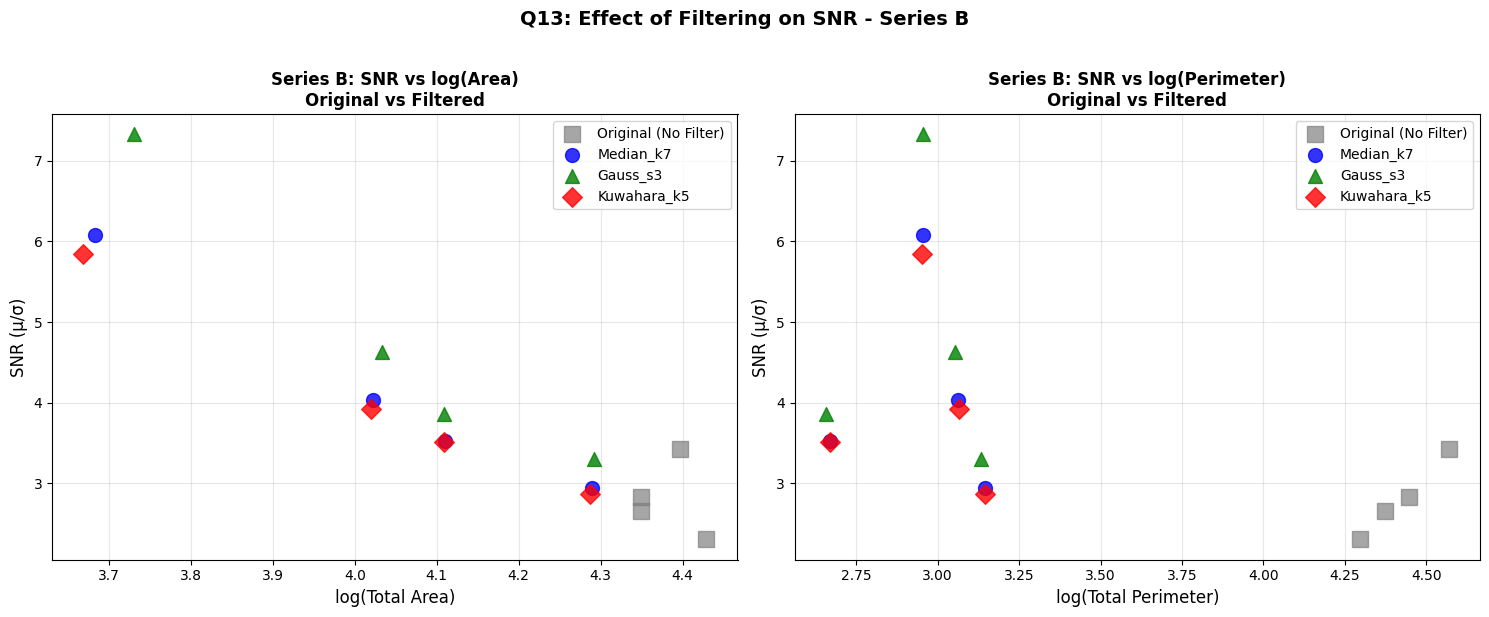

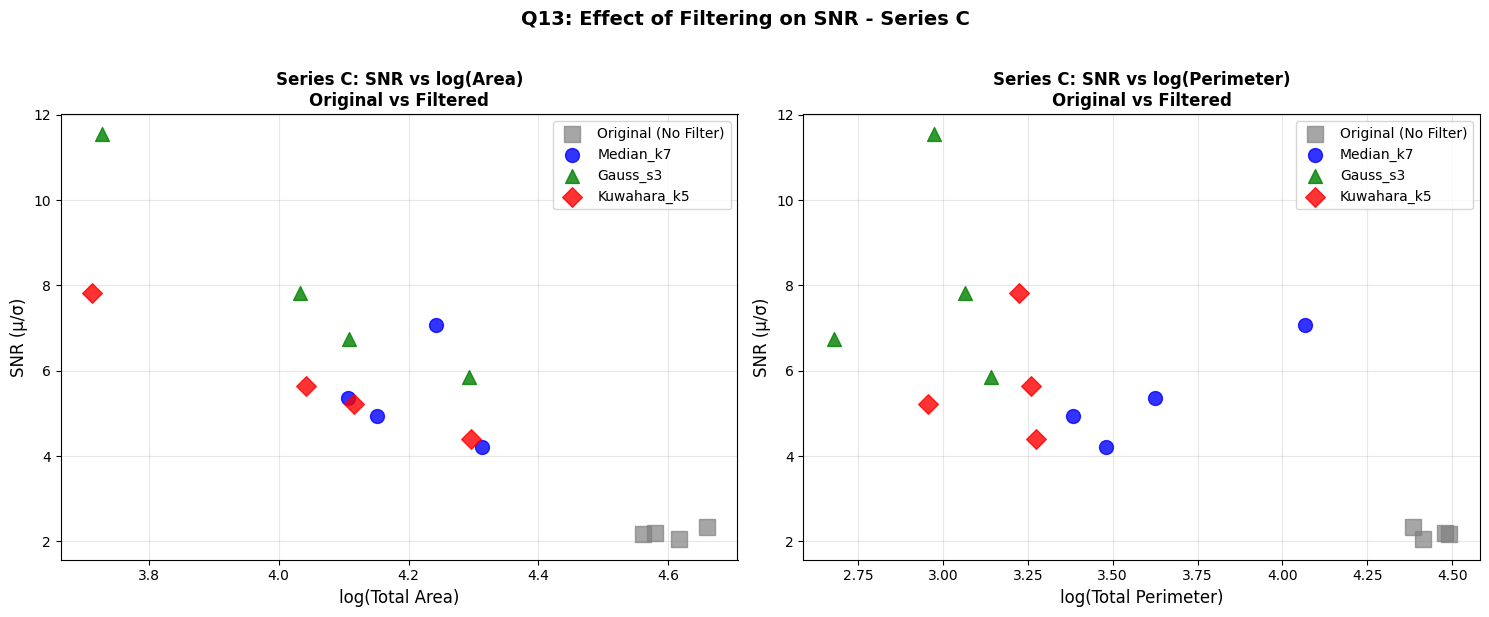

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 3a: Series B - Area
ax = axes[0]
# Original
log_area_b = np.log10(total_area_original['B'])
ax.scatter(log_area_b, snr_original['B'], color='gray', marker='s', 
           s=120, label='Original (No Filter)', alpha=0.7, zorder=2)

# Filtered
filter_colors = {'Median_k7': 'blue', 'Gauss_s3': 'green', 'Kuwahara_k5': 'red'}
filter_markers = {'Median_k7': 'o', 'Gauss_s3': '^', 'Kuwahara_k5': 'D'}

for filter_name in best_filters:
    log_area = np.log10(area_filtered['b'][filter_name])
    ax.scatter(log_area, snr_filtered['b'][filter_name], 
              color=filter_colors[filter_name], marker=filter_markers[filter_name],
              s=100, label=filter_name, alpha=0.8, zorder=3)

ax.set_xlabel('log(Total Area)', fontsize=12)
ax.set_ylabel('SNR (μ/σ)', fontsize=12)
ax.set_title('Series B: SNR vs log(Area)\nOriginal vs Filtered', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)

# Plot 3b: Series B - Perimeter
ax = axes[1]
log_perim_b = np.log10(total_perim_original['B'])
ax.scatter(log_perim_b, snr_original['B'], color='gray', marker='s', 
           s=120, label='Original (No Filter)', alpha=0.7, zorder=2)

for filter_name in best_filters:
    log_perim = np.log10(perim_filtered['b'][filter_name])
    ax.scatter(log_perim, snr_filtered['b'][filter_name], 
              color=filter_colors[filter_name], marker=filter_markers[filter_name],
              s=100, label=filter_name, alpha=0.8, zorder=3)

ax.set_xlabel('log(Total Perimeter)', fontsize=12)
ax.set_ylabel('SNR (μ/σ)', fontsize=12)
ax.set_title('Series B: SNR vs log(Perimeter)\nOriginal vs Filtered', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)

plt.suptitle('Q13: Effect of Filtering on SNR - Series B', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 4a: Series C - Area
ax = axes[0]
log_area_c = np.log10(total_area_original['C'])
ax.scatter(log_area_c, snr_original['C'], color='gray', marker='s', 
           s=120, label='Original (No Filter)', alpha=0.7, zorder=2)

for filter_name in best_filters:
    log_area = np.log10(area_filtered['c'][filter_name])
    ax.scatter(log_area, snr_filtered['c'][filter_name], 
              color=filter_colors[filter_name], marker=filter_markers[filter_name],
              s=100, label=filter_name, alpha=0.8, zorder=3)

ax.set_xlabel('log(Total Area)', fontsize=12)
ax.set_ylabel('SNR (μ/σ)', fontsize=12)
ax.set_title('Series C: SNR vs log(Area)\nOriginal vs Filtered', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)

# Plot 4b: Series C - Perimeter
ax = axes[1]
log_perim_c = np.log10(total_perim_original['C'])
ax.scatter(log_perim_c, snr_original['C'], color='gray', marker='s', 
           s=120, label='Original (No Filter)', alpha=0.7, zorder=2)

for filter_name in best_filters:
    log_perim = np.log10(perim_filtered['c'][filter_name])
    ax.scatter(log_perim, snr_filtered['c'][filter_name], 
              color=filter_colors[filter_name], marker=filter_markers[filter_name],
              s=100, label=filter_name, alpha=0.8, zorder=3)

ax.set_xlabel('log(Total Perimeter)', fontsize=12)
ax.set_ylabel('SNR (μ/σ)', fontsize=12)
ax.set_title('Series C: SNR vs log(Perimeter)\nOriginal vs Filtered', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)

plt.suptitle('Q13: Effect of Filtering on SNR - Series C', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [54]:
for series in ['B', 'C']:
    print(f"\nSeries {series}:")
    print("-"*60)
    
    original_mean = np.mean(snr_results[series]['original'])
    print(f"Original Mean SNR: {original_mean:.4f}")
    print(f"\n{'Filter':<20} {'Mean SNR':<15} {'Improvement':<15} {'Improvement %':<15}")
    print("-"*60)
    
    improvements = []
    for filter_config in filters_to_test:
        filter_name = filter_config['name']
        mean_snr = np.mean(snr_results[series]['filtered'][filter_name])
        improvement = mean_snr - original_mean
        improvement_pct = (improvement / original_mean) * 100
        improvements.append((filter_name, improvement, improvement_pct))
        print(f"{filter_name:<20} {mean_snr:<15.4f} {improvement:<15.4f} {improvement_pct:<15.2f}%")
    
    # Best filter
    best = max(improvements, key=lambda x: x[1])
    print("-"*60)
    print(f" BEST FILTER: {best[0]} (Improvement: {best[1]:.4f}, {best[2]:.2f}%)")


Series B:
------------------------------------------------------------
Original Mean SNR: 2.8042

Filter               Mean SNR        Improvement     Improvement %  
------------------------------------------------------------
Median_k3            3.7313          0.9272          33.06          %
Median_k7            4.1435          1.3394          47.76          %
Gauss_s3             4.7755          1.9713          70.30          %
Gauss_s5             5.2939          2.4897          88.79          %
Kuwahara_k3          4.0347          1.2306          43.88          %
Kuwahara_k5          4.0347          1.2306          43.88          %
------------------------------------------------------------
 BEST FILTER: Gauss_s5 (Improvement: 2.4897, 88.79%)

Series C:
------------------------------------------------------------
Original Mean SNR: 2.1833

Filter               Mean SNR        Improvement     Improvement %  
------------------------------------------------------------
Median_k